# M10-500k real-event multi-event evaluation and LVK comparison

This notebook evaluates the final M10 input-zscore model on real GWOSC BBH events.

The first objective is to reproduce the GW170814 result obtained in the dedicated notebook using a clean event-loop implementation. Once this regression test passes, additional events and LVK reference comparisons can be added.

Important interpretation:

The CNN outputs are low-latency point estimates calibrated on synthetic BBH data. The conformal intervals are split-conformal prediction intervals for the CNN estimator under the synthetic calibration distribution. They are not Bayesian posterior credible intervals.

_____________________

,preprocessing,detector,real_mean,real_std,real_maxabs,finite,event
0,raw_processed_real,H1,1.267620e-03,23.615892,104.809555,True,GW170814
1,raw_processed_real,L1,-1.193604e-02,86.220123,207.140900,True,GW170814
2,raw_processed_real,V1,2.376913e-02,156.278931,476.448364,True,GW170814
3,zscore_processed_real,H1,-1.047738e-09,1.000000,4.438040,True,GW170814
4,zscore_processed_real,L1,-2.456363e-08,1.000000,2.402328,True,GW170814
5,zscore_processed_real,V1,-8.323696e-09,1.000000,3.048857,True,GW170814


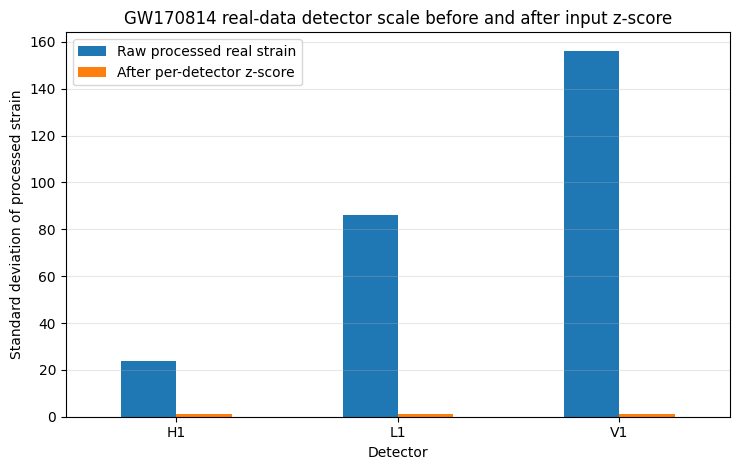

Saved: /data/vserrano/cbc_pe_data/results/bbh_processed_4s_seobnrv4opt_snr10-25_n500_000/real_events_m10_500k_lvk_comparison/figures/gw170814_scale_before_after_zscore.png


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

OUTPUT_DIR = Path("/data/vserrano/cbc_pe_data/results/bbh_processed_4s_seobnrv4opt_snr10-25_n500_000/real_events_m10_500k_lvk_comparison")
FIGURES_DIR = Path("/data/vserrano/cbc_pe_data/results/bbh_processed_4s_seobnrv4opt_snr10-25_n500_000/real_events_m10_500k_lvk_comparison/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

scale_path = OUTPUT_DIR / "debug_gw170814_scale_summary.csv"
scale_df = pd.read_csv(scale_path)

display(scale_df)

plot_df = scale_df.pivot_table(
    index="detector",
    columns="preprocessing",
    values="real_std",
    aggfunc="first",
).loc[["H1", "L1", "V1"]]

# Make column order explicit
plot_df = plot_df[["raw_processed_real", "zscore_processed_real"]]

ax = plot_df.plot(
    kind="bar",
    figsize=(7.5, 4.8),
    rot=0,
)

ax.set_ylabel("Standard deviation of processed strain")
ax.set_xlabel("Detector")
ax.set_title("GW170814 real-data detector scale before and after input z-score")
ax.grid(axis="y", alpha=0.3)
ax.legend(["Raw processed real strain", "After per-detector z-score"])

plt.tight_layout()

out_path = FIGURES_DIR / "gw170814_scale_before_after_zscore.png"
plt.savefig(out_path, dpi=250)
plt.show()

print("Saved:", out_path)

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

OUTPUT_DIR = Path(
    "/data/vserrano/cbc_pe_data/results/bbh_processed_4s_seobnrv4opt_snr10-25_n500_000/"
    "real_events_m10_500k_lvk_comparison"
)

FIGURES_DIR = OUTPUT_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

ablation_rows = [
    # model, detector_setup, chirp_mass, total_mass, chi_eff
    ("M08", "H1 only", 23.45, 52.61, -0.14),
    ("M08", "H1+L1",   26.05, 60.89,  0.10),
    ("M08", "H1+V1",    3.58, 10.81,  0.58),
    ("M08", "H1+L1+V1", 3.36,  9.60,  0.47),

    ("M10 input-zscore", "H1 only", 21.49, 49.48, -0.275),
    ("M10 input-zscore", "H1+L1",   24.54, 57.06, -0.068),
    ("M10 input-zscore", "H1+V1",   25.39, 60.32,  0.005),
    ("M10 input-zscore", "H1+L1+V1", 28.27, 67.44, 0.147),
]

ablation_df = pd.DataFrame(
    ablation_rows,
    columns=["model", "detector_setup", "chirp_mass", "total_mass", "chi_eff"],
)

ablation_csv_path = OUTPUT_DIR / "gw170814_detector_ablation_m08_m10.csv"
ablation_df.to_csv(ablation_csv_path, index=False)

display(ablation_df)
print("Saved:", ablation_csv_path)

,model,detector_setup,chirp_mass,total_mass,chi_eff
0,M08,H1 only,23.45,52.61,-0.140
1,M08,H1+L1,26.05,60.89,0.100
2,M08,H1+V1,3.58,10.81,0.580
3,M08,H1+L1+V1,3.36,9.60,0.470
4,M10 input-zscore,H1 only,21.49,49.48,-0.275
5,M10 input-zscore,H1+L1,24.54,57.06,-0.068
6,M10 input-zscore,H1+V1,25.39,60.32,0.005
7,M10 input-zscore,H1+L1+V1,28.27,67.44,0.147


Saved: /data/vserrano/cbc_pe_data/results/bbh_processed_4s_seobnrv4opt_snr10-25_n500_000/real_events_m10_500k_lvk_comparison/gw170814_detector_ablation_m08_m10.csv


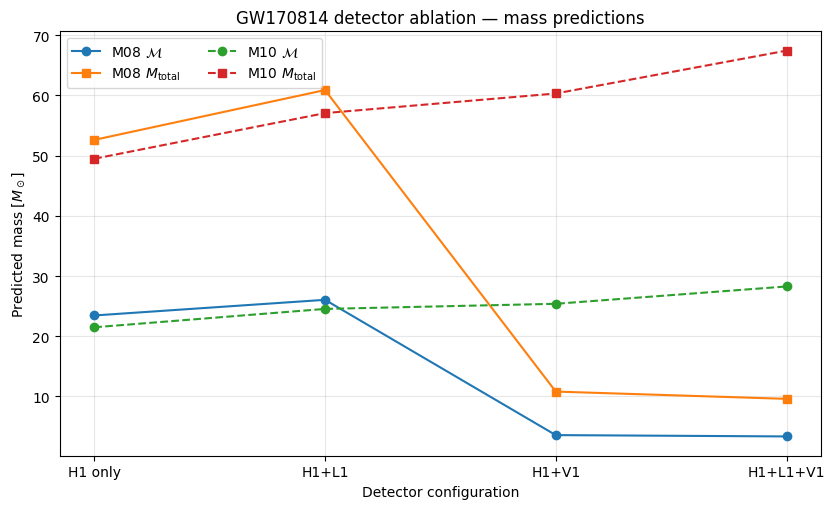

Saved: /data/vserrano/cbc_pe_data/results/bbh_processed_4s_seobnrv4opt_snr10-25_n500_000/real_events_m10_500k_lvk_comparison/figures/gw170814_detector_ablation_masses_m08_m10.png


In [3]:
detector_order = ["H1 only", "H1+L1", "H1+V1", "H1+L1+V1"]

plot_df = ablation_df.copy()
plot_df["detector_setup"] = pd.Categorical(
    plot_df["detector_setup"],
    categories=detector_order,
    ordered=True,
)
plot_df = plot_df.sort_values(["model", "detector_setup"])

x = np.arange(len(detector_order))
width = 0.35

m08 = plot_df[plot_df["model"] == "M08"].set_index("detector_setup").loc[detector_order]
m10 = plot_df[plot_df["model"] == "M10 input-zscore"].set_index("detector_setup").loc[detector_order]

plt.figure(figsize=(8.5, 5.2))

plt.plot(
    x,
    m08["chirp_mass"],
    marker="o",
    linestyle="-",
    label=r"M08 $\mathcal{M}$",
)

plt.plot(
    x,
    m08["total_mass"],
    marker="s",
    linestyle="-",
    label=r"M08 $M_{\rm total}$",
)

plt.plot(
    x,
    m10["chirp_mass"],
    marker="o",
    linestyle="--",
    label=r"M10 $\mathcal{M}$",
)

plt.plot(
    x,
    m10["total_mass"],
    marker="s",
    linestyle="--",
    label=r"M10 $M_{\rm total}$",
)

plt.xticks(x, detector_order)
plt.ylabel(r"Predicted mass [$M_\odot$]")
plt.xlabel("Detector configuration")
plt.title("GW170814 detector ablation — mass predictions")
plt.grid(alpha=0.3)
plt.legend(ncol=2)
plt.tight_layout()

mass_fig_path = FIGURES_DIR / "gw170814_detector_ablation_masses_m08_m10.png"
plt.savefig(mass_fig_path, dpi=250)
plt.show()

print("Saved:", mass_fig_path)

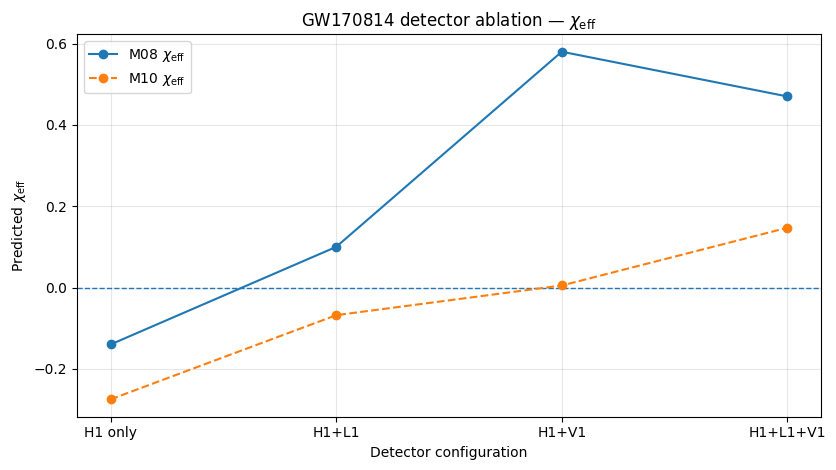

Saved: /data/vserrano/cbc_pe_data/results/bbh_processed_4s_seobnrv4opt_snr10-25_n500_000/real_events_m10_500k_lvk_comparison/figures/gw170814_detector_ablation_chi_eff_m08_m10.png


In [4]:
plt.figure(figsize=(8.5, 4.8))

plt.axhline(0.0, linestyle="--", linewidth=1)

plt.plot(
    x,
    m08["chi_eff"],
    marker="o",
    linestyle="-",
    label=r"M08 $\chi_{\rm eff}$",
)

plt.plot(
    x,
    m10["chi_eff"],
    marker="o",
    linestyle="--",
    label=r"M10 $\chi_{\rm eff}$",
)

plt.xticks(x, detector_order)
plt.ylabel(r"Predicted $\chi_{\rm eff}$")
plt.xlabel("Detector configuration")
plt.title(r"GW170814 detector ablation — $\chi_{\rm eff}$")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

chi_fig_path = FIGURES_DIR / "gw170814_detector_ablation_chi_eff_m08_m10.png"
plt.savefig(chi_fig_path, dpi=250)
plt.show()

print("Saved:", chi_fig_path)

_________________

## 1. Imports

In [1]:
from pathlib import Path
import json
import os
import sys
import warnings
import urllib.request

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch.utils.data import TensorDataset, DataLoader

from pycbc.types import TimeSeries as PyCBCTimeSeries
from pycbc.psd import interpolate, inverse_spectrum_truncation

warnings.filterwarnings("ignore")

print("Current working directory:", os.getcwd())
print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())

/afs/ciemat.es/user/v/vserrano/miniconda3/envs/gw-env/lib/python3.10/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal


Current working directory: /afs/ciemat.es/user/v/vserrano/Desktop/gw/Gravitational-Waves-Lab/cbc_pe/notebooks
torch: 2.11.0+cu130
cuda available: False


## 2. Paths

In [2]:
# Prefer local CIEMAT path; fallback to VM-style paths.
PROJECT_ROOT_CANDIDATES = [
    Path("/afs/ciemat.es/user/v/vserrano/Desktop/gw/Gravitational-Waves-Lab/cbc_pe"),
    Path("/data/vserrano/gw/Gravitational-Waves-Lab/cbc_pe"),
]

DATA_ROOT_CANDIDATES = [
    Path("/data/vserrano/cbc_pe_data"),
    Path("/data/vserrano/cbc_pe/data"),
]

PROJECT_ROOT = next((p for p in PROJECT_ROOT_CANDIDATES if p.exists()), None)
DATA_ROOT = next((p for p in DATA_ROOT_CANDIDATES if p.exists()), None)

if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not find PROJECT_ROOT in candidate paths.")

if DATA_ROOT is None:
    raise FileNotFoundError("Could not find DATA_ROOT in candidate paths.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATASET_ID = "bbh_processed_4s_seobnrv4opt_snr10-25_n500_000"

CONFIG_DIR = PROJECT_ROOT / "configs"
RESULTS_DIR = DATA_ROOT / "results" / DATASET_ID
OUTPUT_DIR = RESULTS_DIR / "real_events_m10_500k_lvk_comparison"
GWOSC_CACHE_DIR = DATA_ROOT / "gwosc_cache"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
GWOSC_CACHE_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_ROOT:", DATA_ROOT)
print("CONFIG_DIR exists:", CONFIG_DIR.exists())
print("RESULTS_DIR exists:", RESULTS_DIR.exists())
print("OUTPUT_DIR:", OUTPUT_DIR)
print("GWOSC_CACHE_DIR:", GWOSC_CACHE_DIR)

PROJECT_ROOT: /afs/ciemat.es/user/v/vserrano/Desktop/gw/Gravitational-Waves-Lab/cbc_pe
DATA_ROOT: /data/vserrano/cbc_pe_data
CONFIG_DIR exists: True
RESULTS_DIR exists: True
OUTPUT_DIR: /data/vserrano/cbc_pe_data/results/bbh_processed_4s_seobnrv4opt_snr10-25_n500_000/real_events_m10_500k_lvk_comparison
GWOSC_CACHE_DIR: /data/vserrano/cbc_pe_data/gwosc_cache


## 3. Project imports

In [3]:
from src.models.network import SimpleCNN_ResidualDilated
from src.models.evaluate import extract_predictions_and_embeddings
from src.conformal.pipeline import run_mondrian_regression

from src.config import SimulationConfig
from src.processing import SignalProcessor

print("Project imports loaded.")

Project imports loaded.


## 4. Model, prediction and Mondrian paths

In [4]:
MODEL_TAG = "M10_inputzscore_resdilated_emb64_d124_train400k"

CHECKPOINT_PATH = DATA_ROOT / "models" / "checkpoints" / (
    f"{DATASET_ID}_SimpleCNN_ResidualDilated_{MODEL_TAG}_MSELoss_seed123_checkpoint.pt"
)

PRED_500K_PATHS = [
    DATA_ROOT / "results" / DATASET_ID / "m10_inputzscore_500k_cal_test_predictions_embeddings.npz",
    DATA_ROOT / "results" / "m10_inputzscore_500k_cal_test_predictions_embeddings.npz",
]

PRED_500K_PATH = next((p for p in PRED_500K_PATHS if p.exists()), None)

MONDRIAN_DIR_CANDIDATES = [
    DATA_ROOT / "results" / DATASET_ID / "mondrian_m10_inputzscore_500k_final",
    DATA_ROOT / "results" / "mondrian_M10_final_baseline",
]

MONDRIAN_DIR = next((p for p in MONDRIAN_DIR_CANDIDATES if p.exists()), None)

print("CHECKPOINT_PATH:", CHECKPOINT_PATH, CHECKPOINT_PATH.exists())
print("PRED_500K_PATH:", PRED_500K_PATH)
print("MONDRIAN_DIR:", MONDRIAN_DIR)

if not CHECKPOINT_PATH.exists():
    raise FileNotFoundError(CHECKPOINT_PATH)

if PRED_500K_PATH is None:
    raise FileNotFoundError("Could not find M10-500k cal/test prediction NPZ.")

if MONDRIAN_DIR is None:
    raise FileNotFoundError("Could not find M10-500k Mondrian output directory.")

CHECKPOINT_PATH: /data/vserrano/cbc_pe_data/models/checkpoints/bbh_processed_4s_seobnrv4opt_snr10-25_n500_000_SimpleCNN_ResidualDilated_M10_inputzscore_resdilated_emb64_d124_train400k_MSELoss_seed123_checkpoint.pt True
PRED_500K_PATH: /data/vserrano/cbc_pe_data/results/bbh_processed_4s_seobnrv4opt_snr10-25_n500_000/m10_inputzscore_500k_cal_test_predictions_embeddings.npz
MONDRIAN_DIR: /data/vserrano/cbc_pe_data/results/mondrian_M10_final_baseline


## 5. Load synthetic calibration predictions

In [5]:
pred_data = np.load(PRED_500K_PATH, allow_pickle=True)

print("Prediction NPZ files:")
for k in pred_data.files:
    arr = pred_data[k]
    print(f"{k:25s}", arr.shape, arr.dtype)

pred_cal = pred_data["pred_cal"].astype(np.float64)
y_cal = pred_data["y_cal"].astype(np.float64)
emb_cal = pred_data["emb_cal"].astype(np.float64)

pred_test = pred_data["pred_test"].astype(np.float64)
y_test = pred_data["y_test"].astype(np.float64)
emb_test = pred_data["emb_test"].astype(np.float64)

y_mean = pred_data["y_mean"].astype(np.float64)
y_std = pred_data["y_std"].astype(np.float64)
label_names = [str(x) for x in pred_data["label_names"].tolist()]

input_normalization = pred_data["input_normalization"].item()

print("\nlabel_names:", label_names)
print("input_normalization:", input_normalization)

assert label_names == ["chirp_mass", "total_mass", "chi_eff"]
assert input_normalization["enabled"] is True
assert input_normalization["mode"] == "per_sample_per_detector_zscore"

print("pred_cal:", pred_cal.shape)
print("y_cal:", y_cal.shape)
print("emb_cal:", emb_cal.shape)

Prediction NPZ files:
y_mean                    (3,) float32
y_std                     (3,) float32
label_names               (3,) <U10
checkpoint_file           () <U196
dataset_path              () <U86
split_path                () <U142
label_stats_path          () <U158
model_config              () object
input_normalization       () object
available_splits          (2,) <U4
pred_cal                  (30000, 3) float32
emb_cal                   (30000, 64) float32
y_cal                     (30000, 3) float32
idx_cal                   (30000,) int64
pred_test                 (30000, 3) float32
emb_test                  (30000, 64) float32
y_test                    (30000, 3) float32
idx_test                  (30000,) int64

label_names: ['chirp_mass', 'total_mass', 'chi_eff']
input_normalization: {'enabled': True, 'mode': 'per_sample_per_detector_zscore', 'eps': 1e-06}
pred_cal: (30000, 3)
y_cal: (30000, 3)
emb_cal: (30000, 64)


## 6. Load selected Mondrian configurations

In [6]:
SELECTION_PATH = MONDRIAN_DIR / "selected_configurations.csv"

print("SELECTION_PATH:", SELECTION_PATH, SELECTION_PATH.exists())

if not SELECTION_PATH.exists():
    raise FileNotFoundError(SELECTION_PATH)

selection_df = pd.read_csv(SELECTION_PATH)

display(selection_df)

required_cols = {
    "final_policy", "label", "taxonomy_mode", "interval_mode", "n_bins"
}
missing_cols = required_cols - set(selection_df.columns)
if missing_cols:
    raise ValueError(f"Missing columns in selection_df: {missing_cols}")

SELECTION_PATH: /data/vserrano/cbc_pe_data/results/mondrian_M10_final_baseline/selected_configurations.csv True


,taxonomy_mode,interval_mode,n_bins,label,label_index,global_coverage,global_miscoverage,global_undercoverage_pvalue,global_mean_width_std,global_median_width_std,...,global_2sigma_low,global_2sigma_high,global_3sigma_low,global_3sigma_high,global_within_2sigma,min_width_for_label,width_limit,relative_width_excess,selection_policy,final_policy
0,difficulty,asymmetric,4,chirp_mass,0,0.900533,0.099467,0.623708,0.883767,0.714333,...,0.896536,0.903464,0.894804,0.905196,True,11.731975,11.966614,0.003718,conservative_zero_under_bins_2sigma,conservative
1,difficulty,symmetric,4,chirp_mass,0,0.901167,0.098833,0.752327,0.886183,0.711688,...,0.896536,0.903464,0.894804,0.905196,True,11.731975,11.966614,0.000000,efficient_local_validity_tolerant,efficient
2,prediction,asymmetric,6,total_mass,1,0.899533,0.100467,0.396584,0.827581,0.756104,...,0.896536,0.903464,0.894804,0.905196,True,25.844899,26.361797,0.013706,conservative_zero_under_bins_2sigma,conservative
3,difficulty,symmetric,4,total_mass,1,0.900567,0.099433,0.631003,0.840208,0.745881,...,0.896536,0.903464,0.894804,0.905196,True,25.844899,26.361797,0.000000,efficient_local_validity_tolerant,efficient
4,prediction,symmetric,8,chi_eff,2,0.900267,0.099733,0.563986,1.336248,1.321660,...,0.896536,0.903464,0.894804,0.905196,True,0.579787,0.591383,0.004957,conservative_zero_under_bins_2sigma,conservative
5,difficulty,asymmetric,12,chi_eff,2,0.899033,0.100967,0.291065,1.318723,1.231796,...,0.896536,0.903464,0.894804,0.905196,True,0.543044,0.553905,0.000000,efficient_local_validity_tolerant,efficient


## 7. Load M10-500k model

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)

print("Checkpoint keys:")
print(checkpoint.keys())

model_config = checkpoint.get("model_config", None)
if model_config is None:
    raise KeyError("Checkpoint does not contain model_config.")

model_kwargs = model_config.get("model_kwargs", None)
if model_kwargs is None:
    model_kwargs = model_config.get("kwargs", None)

if model_kwargs is None:
    raise KeyError("Could not find model_kwargs or kwargs inside model_config.")

print("model_kwargs:")
print(json.dumps(model_kwargs, indent=2))

model = SimpleCNN_ResidualDilated(**model_kwargs)
model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
model.eval()

print("Model loaded.")

device: cpu
Checkpoint keys:
dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'train_loss', 'best_val_loss', 'y_mean', 'y_std', 'model_config', 'training_config', 'elapsed_seconds', 'history'])
model_kwargs:
{
  "n_detectors": 3,
  "n_outputs": 3,
  "embedding_dim": 64,
  "residual_channels": 64,
  "dilations": [
    1,
    2,
    4
  ],
  "residual_kernel_size": 7,
  "dropout_conv": 0.05,
  "dropout_dense": 0.1,
  "num_groups": 8
}
Model loaded.


## 8. Build preprocessing processor

In [8]:
GEN_CONFIG_PATH = PROJECT_ROOT / "configs" / "generation" / "generate_500k_bbh_4s.json"
TRAIN_CONFIG_PATH = PROJECT_ROOT / "configs" / "experiments" / "train_500k_M10_inputzscore_resdilated_emb64_d124_bs256_seed123.json"

print("GEN_CONFIG_PATH:", GEN_CONFIG_PATH, GEN_CONFIG_PATH.exists())
print("TRAIN_CONFIG_PATH:", TRAIN_CONFIG_PATH, TRAIN_CONFIG_PATH.exists())

if not GEN_CONFIG_PATH.exists():
    raise FileNotFoundError(GEN_CONFIG_PATH)

with open(GEN_CONFIG_PATH, "r") as f:
    gen_cfg = json.load(f)

# Explicit training/preprocessing contract.
DETECTOR_ORDER = gen_cfg["detectors"]
fs = int(gen_cfg["simulation"].get("sampling_frequency", 4096))
duration = float(gen_cfg["simulation"]["duration"])
final_duration = duration
final_length = int(final_duration * fs)
context_start = int(gen_cfg["simulation"]["processing_context_start_samples"])
context_end = int(gen_cfg["simulation"]["processing_context_end_samples"])
processing_length = final_length + context_start + context_end
processing_duration = processing_length / fs
processing_delta_f = 1.0 / processing_duration
processing_flength = processing_length // 2 + 1

sim_config = SimulationConfig(
    duration=duration,
    processing_context_start_samples=context_start,
    processing_context_end_samples=context_end,
)

processor = SignalProcessor(
    config=sim_config,
    **gen_cfg["signal_processor"],
)

print("DETECTOR_ORDER:", DETECTOR_ORDER)
print("fs:", fs)
print("final_duration:", final_duration)
print("final_length:", final_length)
print("context_start:", context_start)
print("context_end:", context_end)
print("processing_length:", processing_length)
print("processing_duration:", processing_duration)
print("processing_delta_f:", processing_delta_f)
print("processing_flength:", processing_flength)

print("\nSignalProcessor:")
print("whitening_method:", processor.whitening_method)
print("apply_highpass:", processor.apply_highpass)
print("apply_lowpass:", processor.apply_lowpass)
print("apply_standardization:", processor.apply_standardization)
print("output_mode:", processor.output_mode)

assert DETECTOR_ORDER == ["H1", "L1", "V1"]
assert fs == 4096
assert final_length == 16384
assert processing_length == 19712
assert processor.whitening_method == "psd"
assert processor.apply_highpass is True
assert processor.apply_lowpass is True
assert processor.apply_standardization is False
assert processor.output_mode == "crop_to_config"

GEN_CONFIG_PATH: /afs/ciemat.es/user/v/vserrano/Desktop/gw/Gravitational-Waves-Lab/cbc_pe/configs/generation/generate_500k_bbh_4s.json True
TRAIN_CONFIG_PATH: /afs/ciemat.es/user/v/vserrano/Desktop/gw/Gravitational-Waves-Lab/cbc_pe/configs/experiments/train_500k_M10_inputzscore_resdilated_emb64_d124_bs256_seed123.json True
DETECTOR_ORDER: ['H1', 'L1', 'V1']
fs: 4096
final_duration: 4.0
final_length: 16384
context_start: 1664
context_end: 1664
processing_length: 19712
processing_duration: 4.8125
processing_delta_f: 0.2077922077922078
processing_flength: 9857

SignalProcessor:
whitening_method: psd
apply_highpass: True
apply_lowpass: True
apply_standardization: False
output_mode: crop_to_config


## 9. Core helpers

In [9]:
def zscore_per_sample_per_detector_np(X, eps=1e-6):
    """Per-sample, per-detector z-score normalization for X with shape (N, C, T)."""
    X = np.asarray(X, dtype=np.float32)
    mean = X.mean(axis=2, keepdims=True)
    std = X.std(axis=2, keepdims=True)
    return (X - mean) / (std + eps)


def predict_real_with_embeddings(model, X_real_z, device, batch_size=1):
    """Predict standardized labels, physical labels and embeddings for real input."""
    X_tensor = torch.from_numpy(X_real_z.astype(np.float32))
    y_dummy = torch.zeros((X_tensor.shape[0], len(label_names)), dtype=torch.float32)

    loader = DataLoader(
        TensorDataset(X_tensor, y_dummy),
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
    )

    pred_std, emb, _ = extract_predictions_and_embeddings(
        model=model,
        loader=loader,
        device=device,
    )

    pred_phys = pred_std * y_std[None, :] + y_mean[None, :]
    return pred_std, pred_phys, emb


def summarize_real_scale(X, detectors, tag):
    """Summarize mean/std/maxabs per detector for one real-event input."""
    rows = []

    for j, ifo in enumerate(detectors):
        arr = X[0, j]

        rows.append({
            "preprocessing": tag,
            "detector": ifo,
            "real_mean": float(np.mean(arr)),
            "real_std": float(np.std(arr)),
            "real_maxabs": float(np.max(np.abs(arr))),
            "finite": bool(np.all(np.isfinite(arr))),
        })

    return pd.DataFrame(rows)

## 10. GWOSC IO helpers

In [10]:
def is_valid_hdf5(path):
    """
    Check whether an HDF5 file can be opened and contains the expected GWOSC groups.
    """
    path = Path(path)

    if not path.exists():
        return False

    try:
        with h5py.File(path, "r") as f:
            _ = f["strain"]["Strain"].shape
            _ = f["meta"]["GPSstart"][()]
            _ = f["meta"]["Duration"][()]
        return True

    except Exception as e:
        print(f"Invalid HDF5 file: {path}")
        print("Reason:", repr(e))
        return False


def download_if_needed(url, cache_dir=GWOSC_CACHE_DIR, force=False):
    """
    Download a GWOSC file if missing or invalid.

    If a cached file exists but is truncated/corrupted, it is deleted and re-downloaded.
    """
    filename = url.split("/")[-1]
    local_path = cache_dir / filename

    if force and local_path.exists():
        print(f"Force removing cached file: {filename}")
        local_path.unlink()

    if local_path.exists():
        if is_valid_hdf5(local_path):
            print(f"Using cached file: {filename}")
            return local_path

        print(f"Removing corrupted cached file: {filename}")
        local_path.unlink()

    print(f"Downloading {filename}...")
    urllib.request.urlretrieve(url, local_path)

    if not is_valid_hdf5(local_path):
        raise OSError(f"Downloaded file is not a valid GWOSC HDF5 file: {local_path}")

    return local_path


def read_gwosc_hdf5_as_pycbc_timeseries(path):
    """Read a GWOSC HDF5 file as a PyCBC TimeSeries."""
    path = Path(path)

    with h5py.File(path, "r") as f:
        strain = f["strain"]["Strain"][:].astype(np.float64)
        gps_start = float(f["meta"]["GPSstart"][()])
        duration_file = float(f["meta"]["Duration"][()])
        delta_t = duration_file / len(strain)

    return PyCBCTimeSeries(
        strain,
        delta_t=delta_t,
        epoch=gps_start,
    )

In [11]:
def get_timeseries_bounds(ts):
    """
    Return start/end GPS time for a PyCBC TimeSeries.
    """
    start = float(ts.start_time)
    end = start + float(ts.duration)
    return start, end


def choose_adaptive_pre_event_psd_offsets(
    raw_strains_long,
    event_time,
    preferred_offsets=(-1024.0, -640.0),
    min_gap_to_event=128.0,
    psd_duration=None,
    safety_margin=1.0,
):
    """
    Choose a pre-event PSD window that lies inside the common available time range
    of all detectors.

    The preferred window is used if valid. Otherwise, it is shifted forward just
    enough to fit inside the intersection of detector availability, while still
    ending before event_time - min_gap_to_event.
    """
    preferred_start_offset, preferred_end_offset = preferred_offsets

    if psd_duration is None:
        psd_duration = preferred_end_offset - preferred_start_offset

    starts = []
    ends = []

    for det, ts in raw_strains_long.items():
        s, e = get_timeseries_bounds(ts)
        starts.append(s)
        ends.append(e)

    common_start = max(starts) + safety_margin
    common_end = min(ends) - safety_margin

    preferred_start = event_time + preferred_start_offset
    preferred_end = event_time + preferred_end_offset

    latest_allowed_end = event_time - min_gap_to_event

    # Preferred window is valid.
    if (
        preferred_start >= common_start
        and preferred_end <= common_end
        and preferred_end <= latest_allowed_end
    ):
        return preferred_start_offset, preferred_end_offset

    # Shift forward to fit common detector availability.
    candidate_start = max(preferred_start, common_start)
    candidate_end = candidate_start + psd_duration

    # If that gets too close to the event, shift backward as much as possible.
    if candidate_end > latest_allowed_end:
        candidate_end = latest_allowed_end
        candidate_start = candidate_end - psd_duration

    if candidate_start < common_start or candidate_end > common_end:
        raise ValueError(
            "Could not find valid pre-event PSD window. "
            f"common=[{common_start}, {common_end}], "
            f"event_time={event_time}, "
            f"candidate=[{candidate_start}, {candidate_end}]"
        )

    return candidate_start - event_time, candidate_end - event_time

## 11. Real-event preprocessing helpers

In [12]:
def estimate_offsource_psd_long(
    strain,
    event_time,
    psd_start_offset=-512.0,
    psd_end_offset=-128.0,
    psd_segment_duration=8.0,
    low_frequency_cutoff=30.0,
    max_filter_duration=0.5,
):
    """Estimate an off-source PSD from a long GWOSC strain segment."""
    psd_start = event_time + psd_start_offset
    psd_end = event_time + psd_end_offset

    available_start = float(strain.start_time)
    available_end = float(strain.end_time)

    if psd_start < available_start or psd_end > available_end:
        raise ValueError(
            f"PSD window [{psd_start}, {psd_end}] outside available "
            f"[{available_start}, {available_end}]"
        )

    psd_data = strain.time_slice(psd_start, psd_end)

    psd = psd_data.psd(psd_segment_duration)
    psd = interpolate(psd, processing_delta_f)

    max_filter_len = int(round(max_filter_duration * fs))

    psd = inverse_spectrum_truncation(
        psd,
        max_filter_len=max_filter_len,
        low_frequency_cutoff=low_frequency_cutoff,
        trunc_method="hann",
    )

    if len(psd) > processing_flength:
        psd = psd[:processing_flength]
    elif len(psd) < processing_flength:
        raise ValueError(f"PSD too short: {len(psd)} < {processing_flength}")

    if not np.all(np.isfinite(psd.numpy())):
        raise ValueError("PSD contains non-finite values.")

    return psd


def build_real_input_like_training_clean(
    *,
    raw_strains_long,
    detectors,
    center_time,
    processor,
    psd_start_offset=-512.0,
    psd_end_offset=-128.0,
    psd_segment_duration=8.0,
):
    """Build one real input using the same preprocessing contract as training."""
    detectors = list(detectors)

    if detectors != DETECTOR_ORDER:
        raise ValueError(
            f"This M10 model expects detector order {DETECTOR_ORDER}; got {detectors}. "
            "For now use H1/L1/V1 events only."
        )

    output_start = center_time - final_duration / 2
    output_end = center_time + final_duration / 2

    processing_start = output_start - context_start / fs
    processing_end = output_end + context_end / fs

    real_segments = {}

    for ifo in detectors:
        seg = raw_strains_long[ifo].time_slice(processing_start, processing_end)

        if len(seg) != processing_length:
            raise ValueError(f"{ifo}: expected {processing_length}, got {len(seg)}")

        real_segments[ifo] = seg

    psds = {}

    for ifo in detectors:
        psds[ifo] = estimate_offsource_psd_long(
            raw_strains_long[ifo],
            event_time=center_time,
            psd_start_offset=psd_start_offset,
            psd_end_offset=psd_end_offset,
            psd_segment_duration=psd_segment_duration,
            low_frequency_cutoff=30.0,
            max_filter_duration=0.5,
        )

    processed = processor.process_network(
        strains=real_segments,
        psds=psds,
    )

    X = np.stack(
        [processed[ifo].numpy() for ifo in detectors],
        axis=0,
    ).astype(np.float32)

    X = X[None, :, :]

    expected_shape = (1, len(detectors), final_length)
    if X.shape != expected_shape:
        raise ValueError(f"Bad X shape: {X.shape}; expected {expected_shape}")

    if not np.all(np.isfinite(X)):
        raise ValueError("X contains non-finite values.")

    meta = {
        "center_time": float(center_time),
        "output_start": float(output_start),
        "output_end": float(output_end),
        "processing_start": float(processing_start),
        "processing_end": float(processing_end),
        "psd_start_offset": float(psd_start_offset),
        "psd_end_offset": float(psd_end_offset),
        "psd_segment_duration": float(psd_segment_duration),
    }

    return X, processed, psds, real_segments, meta

In [13]:
PSD_WINDOW_CANDIDATES = [
    (-1800.0, -1416.0),
    (-1600.0, -1216.0),
    (-1400.0, -1016.0),
    (-1200.0, -816.0),
    (-1024.0, -640.0),
    (-900.0, -516.0),
    (-768.0, -384.0),
    (-640.0, -256.0),
    (-512.0, -128.0),
]

print("PSD_WINDOW_CANDIDATES:")
for w in PSD_WINDOW_CANDIDATES:
    print(w)

PSD_WINDOW_CANDIDATES:
(-1800.0, -1416.0)
(-1600.0, -1216.0)
(-1400.0, -1016.0)
(-1200.0, -816.0)
(-1024.0, -640.0)
(-900.0, -516.0)
(-768.0, -384.0)
(-640.0, -256.0)
(-512.0, -128.0)


In [14]:
def time_slice_is_finite(ts, start, end):
    """
    Check whether a PyCBC TimeSeries slice is finite.
    """
    try:
        seg = ts.time_slice(start, end)
        arr = np.asarray(seg)
        return np.all(np.isfinite(arr))
    except Exception:
        return False


def psd_window_is_available_and_finite(raw_strains_long, event_time, psd_window):
    """
    Check if a PSD window is inside all detector files and contains finite data.
    """
    start = event_time + psd_window[0]
    end = event_time + psd_window[1]

    for det, ts in raw_strains_long.items():
        ts_start = float(ts.start_time)
        ts_end = ts_start + float(ts.duration)

        if start < ts_start or end > ts_end:
            return False

        if not time_slice_is_finite(ts, start, end):
            return False

    return True


def event_window_is_available_and_finite(raw_strains_long, center_time):
    """
    Check whether the processing window around the event is finite for all detectors.
    """
    output_start = center_time - final_duration / 2
    output_end = center_time + final_duration / 2

    processing_start = output_start - context_start / fs
    processing_end = output_end + context_end / fs

    for det, ts in raw_strains_long.items():
        ts_start = float(ts.start_time)
        ts_end = ts_start + float(ts.duration)

        if processing_start < ts_start or processing_end > ts_end:
            return False, f"{det}: event processing window outside available data"

        if not time_slice_is_finite(ts, processing_start, processing_end):
            return False, f"{det}: event processing window contains NaN/Inf"

    return True, "ok"


def select_valid_psd_window(raw_strains_long, event_time, preferred_window=(-1024.0, -640.0)):
    """
    Select a valid finite off-source PSD window.

    Priority:
    1. preferred_window if valid
    2. candidates in PSD_WINDOW_CANDIDATES
    """
    if psd_window_is_available_and_finite(raw_strains_long, event_time, preferred_window):
        return preferred_window

    for w in PSD_WINDOW_CANDIDATES:
        if psd_window_is_available_and_finite(raw_strains_long, event_time, w):
            return w

    raise ValueError("No valid finite PSD window found for this event.")

## 12. Apply selected Mondrian calibration

In [15]:
CONFIDENCE_LEVEL = 0.90
N_NEIGHBORS = 5
MIN_SAMPLES_PER_BIN = 20

def apply_selected_mondrian_to_real(
    event_name,
    final_policy,
    pred_real_std,
    emb_real,
    pred_real_phys,
):
    """Apply final selected Mondrian configurations to one real event."""
    rows = []
    y_dummy = pred_real_std.copy()

    selected = selection_df[selection_df["final_policy"] == final_policy].copy()

    if selected.empty:
        raise ValueError(f"No selected configurations found for final_policy={final_policy}")

    for _, sel in selected.iterrows():
        label = sel["label"]
        j = label_names.index(label)

        taxonomy_mode = sel["taxonomy_mode"]
        interval_mode = sel["interval_mode"]
        n_bins = int(sel["n_bins"])

        kwargs = dict(
            pred_cal=pred_cal,
            pred_test=pred_real_std,
            y_cal=y_cal,
            y_test=y_dummy,
            n_bins=n_bins,
            confidence_level=CONFIDENCE_LEVEL,
            apply_jitter=True,
            interval_mode=interval_mode,
            taxonomy_mode=taxonomy_mode,
            min_samples_per_bin=MIN_SAMPLES_PER_BIN,
            tolerance_sigmas=(1, 2, 3),
        )

        if taxonomy_mode == "difficulty":
            kwargs.update(
                cal_embedding=emb_cal,
                target_embedding=emb_real,
                n_neighbors=N_NEIGHBORS,
            )

        result = run_mondrian_regression(**kwargs)

        lower_std = float(result.lower[0, j])
        upper_std = float(result.upper[0, j])

        lower_phys = lower_std * y_std[j] + y_mean[j]
        upper_phys = upper_std * y_std[j] + y_mean[j]

        rows.append({
            "event": event_name,
            "label": label,
            "final_policy": final_policy,
            "taxonomy_mode": taxonomy_mode,
            "interval_mode": interval_mode,
            "n_bins": n_bins,
            "pred_std": float(pred_real_std[0, j]),
            "pred_phys": float(pred_real_phys[0, j]),
            "lower_phys": float(lower_phys),
            "upper_phys": float(upper_phys),
            "width_phys": float(upper_phys - lower_phys),
        })

    return pd.DataFrame(rows)

## 13. Initial event catalog and GWOSC URLs

In [16]:
EVENTS = [
    {
        "event": "GW170814",
        "gps_time": 1186741861.5,
        "detectors": ["H1", "L1", "V1"],
        "sample_rate": 4096,
        "duration": 4.0,
        "psd_window": (-1024.0, -640.0),
        "center_offset": 0.0,
        "psd_segment_duration": 8.0,
        "notes": "O2 BBH event; reference validation case.",
    },
]

GWOSC_URLS = {
    "GW170814": {
        "H1": "https://gwosc.org/archive/data/O2_4KHZ_R1/1185939456/H-H1_GWOSC_O2_4KHZ_R1-1186738176-4096.hdf5",
        "L1": "https://gwosc.org/archive/data/O2_4KHZ_R1/1185939456/L-L1_GWOSC_O2_4KHZ_R1-1186738176-4096.hdf5",
        "V1": "https://gwosc.org/archive/data/O2_4KHZ_R1/1185939456/V-V1_GWOSC_O2_4KHZ_R1-1186738176-4096.hdf5",
    }
}

events_df = pd.DataFrame(EVENTS)
display(events_df)

,event,gps_time,detectors,sample_rate,duration,psd_window,center_offset,psd_segment_duration,notes
0,GW170814,1.186742e+09,"[H1, L1, V1]",4096,4.0,"(-1024.0, -640.0)",0.0,8.0,O2 BBH event; reference validation case.


## 14. Single-event runner

In [ ]:
def run_single_event(event_cfg, final_policy="conservative"):
    """Run M10-500k inference and final Mondrian intervals for one real event."""
    event_name = event_cfg["event"]
    gps_time = float(event_cfg["gps_time"])
    detectors = list(event_cfg["detectors"])
    center_offset = float(event_cfg.get("center_offset", 0.0))

    psd_window = event_cfg.get("psd_window", (-1024.0, -640.0))
    psd_start_offset, psd_end_offset = float(psd_window[0]), float(psd_window[1])
    psd_segment_duration = float(event_cfg.get("psd_segment_duration", 8.0))

    print("=" * 80)
    print("Event:", event_name)
    print("GPS time:", gps_time)
    print("Detectors:", detectors)
    print("PSD window offsets:", psd_window)
    print("PSD segment duration:", psd_segment_duration)
    print("center_offset:", center_offset)

    if detectors != DETECTOR_ORDER:
        raise ValueError(
            f"Detector order must match training order {DETECTOR_ORDER}; got {detectors}."
        )

    # 1. Load long GWOSC strain.
    if event_name not in GWOSC_URLS_ACTIVE:
        raise KeyError(
            f"{event_name} not found in GWOSC_URLS_ACTIVE. "
            f"Available events: {list(GWOSC_URLS_ACTIVE.keys())}"
        )

    raw_strains_long = {}

    for det in detectors:
        if det not in GWOSC_URLS_ACTIVE[event_name]:
            raise KeyError(
                f"{event_name}/{det} not found in GWOSC_URLS_ACTIVE. "
                f"Available detectors: {list(GWOSC_URLS_ACTIVE[event_name].keys())}"
            )

        url = GWOSC_URLS_ACTIVE[event_name][det]

        local_path = download_if_needed(url, cache_dir=GWOSC_CACHE_DIR)
        print(f"{det} local path:", local_path)

        raw_strains_long[det] = read_gwosc_hdf5_as_pycbc_timeseries(local_path)

    # 1b. Validate event window and choose a finite PSD window

    center_time = gps_time + center_offset

    event_ok, event_msg = event_window_is_available_and_finite(
        raw_strains_long=raw_strains_long,
        center_time=center_time,
    )

    if not event_ok:
        raise ValueError(f"Invalid event window: {event_msg}")

    preferred_psd_window = (psd_start_offset, psd_end_offset)

    if event_cfg.get("adaptive_psd_window", True):
        selected_psd_window = select_valid_psd_window(
            raw_strains_long=raw_strains_long,
            event_time=center_time,
            preferred_window=preferred_psd_window,
        )

        psd_start_offset, psd_end_offset = selected_psd_window

        print("Selected finite PSD offsets:", selected_psd_window)


    # 2. Build raw processed input.
    X_real_raw, processed, psds, real_segments, real_meta = build_real_input_like_training_clean(
        raw_strains_long=raw_strains_long,
        detectors=detectors,
        center_time=gps_time + center_offset,
        processor=processor,
        psd_start_offset=psd_start_offset,
        psd_end_offset=psd_end_offset,
        psd_segment_duration=psd_segment_duration,
    )

    print("X_real_raw:", X_real_raw.shape, X_real_raw.dtype)

    # 3. Apply M10 input normalization.
    X_real_z = zscore_per_sample_per_detector_np(
        X_real_raw,
        eps=input_normalization.get("eps", 1e-6),
    )

    print("X_real_z:", X_real_z.shape, X_real_z.dtype)
    print("zscore mean per det:", X_real_z.mean(axis=2))
    print("zscore std per det:", X_real_z.std(axis=2))

    # 4. Predict point estimate and embedding.
    pred_real_std, pred_real_phys, emb_real = predict_real_with_embeddings(
        model=model,
        X_real_z=X_real_z,
        device=device,
        batch_size=1,
    )

    point_df = pd.DataFrame({
        "event": [event_name] * len(label_names),
        "label": label_names,
        "pred_std": pred_real_std[0],
        "pred_phys": pred_real_phys[0],
    })

    # 5. Apply final Mondrian calibration.
    interval_df = apply_selected_mondrian_to_real(
        event_name=event_name,
        final_policy=final_policy,
        pred_real_std=pred_real_std,
        emb_real=emb_real,
        pred_real_phys=pred_real_phys,
    )

    # 6. Scale summaries.
    raw_scale_df = summarize_real_scale(
        X_real_raw,
        detectors=detectors,
        tag="raw_processed_real",
    )

    z_scale_df = summarize_real_scale(
        X_real_z,
        detectors=detectors,
        tag="zscore_processed_real",
    )

    scale_df = pd.concat([raw_scale_df, z_scale_df], ignore_index=True)
    scale_df["event"] = event_name

    return {
        "event": event_name,
        "config": event_cfg,
        "meta": real_meta,
        "raw_strains_long": raw_strains_long,
        "processed": processed,
        "psds": psds,
        "real_segments": real_segments,
        "X_real_raw": X_real_raw,
        "X_real_z": X_real_z,
        "pred_real_std": pred_real_std,
        "pred_real_phys": pred_real_phys,
        "emb_real": emb_real,
        "point_df": point_df,
        "interval_df": interval_df,
        "scale_df": scale_df,
    }

## LVK comparison convention: source-frame vs detector-frame masses

The CNN was trained on waveform masses as they enter the detector-frame signal model. Therefore, its mass predictions should be interpreted as detector-frame quantities.

LVK catalog summaries are often quoted in the source frame. To compare consistently with the CNN outputs, source-frame masses must be converted to detector frame using

$$
m_{\rm det} = (1 + z)\,m_{\rm source}.
$$

The same conversion is applied to chirp mass and total mass:

$$
\mathcal{M}_{\rm det} = (1 + z)\mathcal{M}_{\rm source},
$$

$$
M_{{\rm total},\rm det} = (1 + z)M_{{\rm total},\rm source}.
$$

The effective spin $\chi_{\rm eff}$ is dimensionless and is not redshifted.

The comparison below should therefore use:
- LVK detector-frame chirp mass
- LVK detector-frame total mass
- LVK effective spin

A real event is included only if all required detector channels have finite strain data in:
1. the event processing window,
2. at least one valid off-source PSD window.

## GWOSC API

In [ ]:
import requests
from urllib.parse import urlparse, parse_qs

GWOSC_API_BASE = "https://gwosc.org/api/v2"

def fetch_paginated_json(url, params=None, timeout=60):
    """
    Fetch all pages from a GWOSC API endpoint.

    Returns a list of result dictionaries.
    """
    results = []
    next_url = url
    next_params = params.copy() if params is not None else None

    while next_url is not None:
        print("Fetching:", next_url)

        response = requests.get(
            next_url,
            params=next_params,
            timeout=timeout,
        )
        response.raise_for_status()

        payload = response.json()

        if "results" not in payload:
            raise KeyError(f"No 'results' field in response from {next_url}")

        results.extend(payload["results"])

        next_url = payload.get("next", None)

        # If GWOSC provides an absolute next URL, don't reuse the old params.
        next_params = None

    return results


def fetch_gwosc_catalog_events(catalog="GWTC-3-confident", include_default_parameters=True):
    """
    Fetch event list from a GWOSC catalog.

    The default parameters are enough for first-pass LVK comparison:
    chirp_mass_source, total_mass_source, chi_eff, redshift, etc.
    """
    url = f"{GWOSC_API_BASE}/catalogs/{catalog}/events"

    params = {
        "format": "json",
    }

    if include_default_parameters:
        params["include-default-parameters"] = "true"

    events = fetch_paginated_json(url, params=params)

    print(f"Fetched {len(events)} events from {catalog}")

    return events

In [21]:
def parameters_list_to_dict(parameters):
    """
    Convert GWOSC default_parameters list into a flat dictionary.

    For each parameter p:
        p_best
        p_lower
        p_upper
        p_lower_error
        p_upper_error

    GWOSC convention:
        best = median / preferred value
        lower_error is usually negative
        upper_error is usually positive

    We store absolute lower/upper interval bounds:
        lower = best + lower_error
        upper = best + upper_error
    """
    out = {}

    if parameters is None:
        return out

    for p in parameters:
        name = p.get("name")
        if name is None:
            continue

        best = p.get("best", np.nan)
        lower_error = p.get("lower_error", np.nan)
        upper_error = p.get("upper_error", np.nan)

        out[f"{name}_best"] = best
        out[f"{name}_lower_error"] = lower_error
        out[f"{name}_upper_error"] = upper_error

        try:
            out[f"{name}_lower"] = best + lower_error
        except Exception:
            out[f"{name}_lower"] = np.nan

        try:
            out[f"{name}_upper"] = best + upper_error
        except Exception:
            out[f"{name}_upper"] = np.nan

        out[f"{name}_unit"] = p.get("unit", "")
        out[f"{name}_is_lower_limit"] = p.get("is_lower_limit", False)
        out[f"{name}_is_upper_limit"] = p.get("is_upper_limit", False)

    return out


def gwosc_events_to_parameter_df(events, catalog_name):
    """
    Flatten GWOSC catalog events into one row per event.
    """
    rows = []

    for ev in events:
        row = {
            "event": ev.get("name"),
            "shortName": ev.get("shortName"),
            "catalog": ev.get("catalog", catalog_name),
            "gps_time": ev.get("gps"),
            "version": ev.get("version"),
            "detectors": ",".join(ev.get("detectors", [])),
            "detail_url": ev.get("detail_url"),
            "parameters_url": ev.get("parameters_url"),
            "timelines_url": ev.get("timelines_url"),
        }

        row.update(parameters_list_to_dict(ev.get("default_parameters", [])))

        rows.append(row)

    return pd.DataFrame(rows)

## Load LVK/GWOSC catalog

In [22]:
GWOSC_CATALOG = "GWTC-3-confident"

gwosc_events = fetch_gwosc_catalog_events(
    catalog=GWOSC_CATALOG,
    include_default_parameters=True,
)

gwosc_catalog_df = gwosc_events_to_parameter_df(
    gwosc_events,
    catalog_name=GWOSC_CATALOG,
)

print("gwosc_catalog_df shape:", gwosc_catalog_df.shape)
display(gwosc_catalog_df.head())
display(gwosc_catalog_df.columns.tolist())

Fetching: https://gwosc.org/api/v2/catalogs/GWTC-3-confident/events
Fetching: https://gwosc.org/api/v2/catalogs/GWTC-3-confident/events?format=json&include-default-parameters=true&page=2
Fetched 35 events from GWTC-3-confident
gwosc_catalog_df shape: (35, 97)


,event,shortName,catalog,gps_time,version,detectors,detail_url,parameters_url,timelines_url,chi_eff_best,...,far_is_lower_limit,far_is_upper_limit,p_astro_best,p_astro_lower_error,p_astro_upper_error,p_astro_lower,p_astro_upper,p_astro_unit,p_astro_is_lower_limit,p_astro_is_upper_limit
0,GW200322_091133,GW200322_091133-v1,GWTC-3-confident,1.268904e+09,1,"H1,L1,V1",https://gwosc.org/api/v2/event-versions/GW2003...,None,None,0.27,...,False,False,0.61501,None,None,NaN,NaN,,False,False
1,GW200316_215756,GW200316_215756-v1,GWTC-3-confident,1.268431e+09,1,"H1,L1,V1",https://gwosc.org/api/v2/event-versions/GW2003...,None,None,0.13,...,False,True,0.99000,None,None,NaN,NaN,,True,False
2,GW200311_115853,GW200311_115853-v1,GWTC-3-confident,1.267963e+09,1,"H1,L1,V1",https://gwosc.org/api/v2/event-versions/GW2003...,None,None,-0.02,...,False,True,0.99000,None,None,NaN,NaN,,True,False
3,GW200308_173609,GW200308_173609-v1,GWTC-3-confident,1.267724e+09,1,"H1,L1,V1",https://gwosc.org/api/v2/event-versions/GW2003...,None,None,0.16,...,False,False,0.85660,None,None,NaN,NaN,,False,False
4,GW200306_093714,GW200306_093714-v1,GWTC-3-confident,1.267523e+09,1,"H1,L1,V1",https://gwosc.org/api/v2/event-versions/GW2003...,None,None,0.32,...,False,False,0.81156,None,None,NaN,NaN,,False,False


['event',
 'shortName',
 'catalog',
 'gps_time',
 'version',
 'detectors',
 'detail_url',
 'parameters_url',
 'timelines_url',
 'chi_eff_best',
 'chi_eff_lower_error',
 'chi_eff_upper_error',
 'chi_eff_lower',
 'chi_eff_upper',
 'chi_eff_unit',
 'chi_eff_is_lower_limit',
 'chi_eff_is_upper_limit',
 'chirp_mass_source_best',
 'chirp_mass_source_lower_error',
 'chirp_mass_source_upper_error',
 'chirp_mass_source_lower',
 'chirp_mass_source_upper',
 'chirp_mass_source_unit',
 'chirp_mass_source_is_lower_limit',
 'chirp_mass_source_is_upper_limit',
 'final_mass_source_best',
 'final_mass_source_lower_error',
 'final_mass_source_upper_error',
 'final_mass_source_lower',
 'final_mass_source_upper',
 'final_mass_source_unit',
 'final_mass_source_is_lower_limit',
 'final_mass_source_is_upper_limit',
 'luminosity_distance_best',
 'luminosity_distance_lower_error',
 'luminosity_distance_upper_error',
 'luminosity_distance_lower',
 'luminosity_distance_upper',
 'luminosity_distance_unit',
 'lumin

In [23]:
needed_cols = [
    "event",
    "gps_time",
    "detectors",
    "chirp_mass_source_best",
    "chirp_mass_source_lower",
    "chirp_mass_source_upper",
    "total_mass_source_best",
    "total_mass_source_lower",
    "total_mass_source_upper",
    "chi_eff_best",
    "chi_eff_lower",
    "chi_eff_upper",
    "redshift_best",
    "redshift_lower",
    "redshift_upper",
]

missing = [c for c in needed_cols if c not in gwosc_catalog_df.columns]

print("Missing needed columns:")
print(missing)

display(
    gwosc_catalog_df[
        [c for c in needed_cols if c in gwosc_catalog_df.columns]
    ].head(10)
)

Missing needed columns:
[]


,event,gps_time,detectors,chirp_mass_source_best,chirp_mass_source_lower,chirp_mass_source_upper,total_mass_source_best,total_mass_source_lower,total_mass_source_upper,chi_eff_best,chi_eff_lower,chi_eff_upper,redshift_best,redshift_lower,redshift_upper
0,GW200322_091133,1.268904e+09,"H1,L1,V1",15.00,11.0,44.50,50.0,28.0,182.0,0.27,-0.31,0.81,0.59,0.27,2.02
1,GW200316_215756,1.268431e+09,"H1,L1,V1",8.75,8.2,9.37,21.2,19.2,28.4,0.13,0.03,0.40,0.22,0.14,0.30
2,GW200311_115853,1.267963e+09,"H1,L1,V1",26.60,24.6,29.00,61.9,57.7,67.2,-0.02,-0.22,0.14,0.23,0.16,0.28
3,GW200308_173609,1.267724e+09,"H1,L1,V1",34.00,16.0,78.00,92.0,44.0,261.0,0.16,-0.33,0.74,1.04,0.47,2.51
4,GW200306_093714,1.267523e+09,"H1,L1,V1",17.50,14.5,21.00,43.9,36.4,55.7,0.32,-0.14,0.60,0.38,0.20,0.62
5,GW200302_015811,1.267150e+09,"H1,V1",23.40,20.4,28.10,57.8,50.9,67.4,0.01,-0.25,0.26,0.28,0.16,0.44
6,GW200225_060421,1.266646e+09,"H1,L1,V1",14.20,12.8,15.70,33.5,30.5,37.1,-0.12,-0.40,0.05,0.22,0.12,0.31
7,GW200224_222234,1.266618e+09,"H1,L1,V1",31.10,28.4,34.40,72.3,67.0,79.5,0.10,-0.06,0.25,0.32,0.21,0.40
8,GW200220_124850,1.266238e+09,"H1,L1,V1",28.20,23.1,35.50,67.0,55.0,84.0,-0.07,-0.40,0.20,0.66,0.35,1.02
9,GW200220_061928,1.266215e+09,"H1,L1,V1",62.00,47.0,85.00,148.0,115.0,203.0,0.06,-0.32,0.46,0.90,0.50,1.45


## LVK source-frame to detector-frame conversion

The CNN predicts detector-frame masses because the observed waveform is sensitive to redshifted masses. LVK catalog summaries are usually given in the source frame. Therefore, LVK source-frame masses are converted to detector-frame masses using

$$
M_{\rm det} = (1 + z) M_{\rm source}.
$$

Unlike the simpler fixed-redshift conversion, we propagate the uncertainty in both \(M_{\rm source}\) and \(z\) using a first-order error propagation approximation:

$$
(\Delta M_{\rm det})^2 =
M_{\rm source}^2(\Delta z)^2 +
(1+z)^2(\Delta M_{\rm source})^2.
$$

This is still an approximation because the exact treatment would require posterior samples in order to preserve correlations between mass and redshift. However, it is more consistent than using only the central redshift value for the interval bounds.

The comparison is kept in detector frame. Transforming the CNN prediction back to source frame would require using the LVK redshift estimate, which would inject external LVK information into the CNN result.

In [68]:
def propagate_detector_frame_mass_interval(
    mass_source_best,
    mass_source_lower,
    mass_source_upper,
    redshift_best,
    redshift_lower,
    redshift_upper,
):
    """
    Convert a source-frame mass summary to detector frame and propagate
    source-mass and redshift uncertainties with first-order error propagation.

    Parameters
    ----------
    mass_source_best:
        Central source-frame mass value.
    mass_source_lower:
        Lower bound of the source-frame interval.
    mass_source_upper:
        Upper bound of the source-frame interval.
    redshift_best:
        Central redshift value.
    redshift_lower:
        Lower bound of the redshift interval.
    redshift_upper:
        Upper bound of the redshift interval.

    Returns
    -------
    mass_det_best:
        Central detector-frame mass.
    mass_det_lower:
        Lower detector-frame bound.
    mass_det_upper:
        Upper detector-frame bound.

    Notes
    -----
    This uses asymmetric lower/upper errors:

        delta_M_minus = M_best - M_lower
        delta_M_plus  = M_upper - M_best

        delta_z_minus = z_best - z_lower
        delta_z_plus  = z_upper - z_best

    and propagates them separately.
    """
    M = np.asarray(mass_source_best, dtype=float)
    M_lower = np.asarray(mass_source_lower, dtype=float)
    M_upper = np.asarray(mass_source_upper, dtype=float)

    z = np.asarray(redshift_best, dtype=float)
    z_lower = np.asarray(redshift_lower, dtype=float)
    z_upper = np.asarray(redshift_upper, dtype=float)

    M_det = (1.0 + z) * M

    delta_M_minus = M - M_lower
    delta_M_plus = M_upper - M

    delta_z_minus = z - z_lower
    delta_z_plus = z_upper - z

    delta_det_minus = np.sqrt(
        ((1.0 + z) * delta_M_minus) ** 2
        + (M * delta_z_minus) ** 2
    )

    delta_det_plus = np.sqrt(
        ((1.0 + z) * delta_M_plus) ** 2
        + (M * delta_z_plus) ** 2
    )

    M_det_lower = M_det - delta_det_minus
    M_det_upper = M_det + delta_det_plus

    return M_det, M_det_lower, M_det_upper

In [69]:
def build_lvk_reference_detector_frame(gwosc_df):
    """
    Build LVK reference table in detector frame.

    Masses are converted from source frame to detector frame:

        M_det = (1 + z) M_source

    The mass intervals include first-order propagation of the redshift
    uncertainty.

    chi_eff is dimensionless and is not redshifted.
    """
    df = gwosc_df.copy()

    out = pd.DataFrame()
    out["event"] = df["event"]
    out["gps_time"] = df["gps_time"]
    out["catalog"] = df["catalog"]
    out["detectors"] = df["detectors"]

    out["redshift"] = df["redshift_best"].astype(float)
    out["redshift_lower"] = df["redshift_lower"].astype(float)
    out["redshift_upper"] = df["redshift_upper"].astype(float)

    # ------------------------------------------------------------------
    # Chirp mass: source frame -> detector frame
    # ------------------------------------------------------------------
    (
        out["chirp_mass_lvk"],
        out["chirp_mass_lvk_lower"],
        out["chirp_mass_lvk_upper"],
    ) = propagate_detector_frame_mass_interval(
        mass_source_best=df["chirp_mass_source_best"],
        mass_source_lower=df["chirp_mass_source_lower"],
        mass_source_upper=df["chirp_mass_source_upper"],
        redshift_best=df["redshift_best"],
        redshift_lower=df["redshift_lower"],
        redshift_upper=df["redshift_upper"],
    )

    # ------------------------------------------------------------------
    # Total mass: source frame -> detector frame
    # ------------------------------------------------------------------
    if all(c in df.columns for c in [
        "total_mass_source_best",
        "total_mass_source_lower",
        "total_mass_source_upper",
    ]):
        total_source_best = df["total_mass_source_best"]
        total_source_lower = df["total_mass_source_lower"]
        total_source_upper = df["total_mass_source_upper"]

    else:
        # Fallback from component masses.
        required_mass_cols = [
            "mass_1_source_best",
            "mass_1_source_lower",
            "mass_1_source_upper",
            "mass_2_source_best",
            "mass_2_source_lower",
            "mass_2_source_upper",
        ]

        missing_mass_cols = [c for c in required_mass_cols if c not in df.columns]
        if missing_mass_cols:
            raise KeyError(
                "Cannot construct total mass. Missing columns: "
                + str(missing_mass_cols)
            )

        total_source_best = (
            df["mass_1_source_best"].astype(float)
            + df["mass_2_source_best"].astype(float)
        )

        total_source_lower = (
            df["mass_1_source_lower"].astype(float)
            + df["mass_2_source_lower"].astype(float)
        )

        total_source_upper = (
            df["mass_1_source_upper"].astype(float)
            + df["mass_2_source_upper"].astype(float)
        )

    (
        out["total_mass_lvk"],
        out["total_mass_lvk_lower"],
        out["total_mass_lvk_upper"],
    ) = propagate_detector_frame_mass_interval(
        mass_source_best=total_source_best,
        mass_source_lower=total_source_lower,
        mass_source_upper=total_source_upper,
        redshift_best=df["redshift_best"],
        redshift_lower=df["redshift_lower"],
        redshift_upper=df["redshift_upper"],
    )

    # ------------------------------------------------------------------
    # Component masses in detector frame, useful for event filtering
    # ------------------------------------------------------------------
    if all(c in df.columns for c in [
        "mass_1_source_best",
        "mass_1_source_lower",
        "mass_1_source_upper",
        "mass_2_source_best",
        "mass_2_source_lower",
        "mass_2_source_upper",
    ]):
        (
            out["mass_1_lvk"],
            out["mass_1_lvk_lower"],
            out["mass_1_lvk_upper"],
        ) = propagate_detector_frame_mass_interval(
            mass_source_best=df["mass_1_source_best"],
            mass_source_lower=df["mass_1_source_lower"],
            mass_source_upper=df["mass_1_source_upper"],
            redshift_best=df["redshift_best"],
            redshift_lower=df["redshift_lower"],
            redshift_upper=df["redshift_upper"],
        )

        (
            out["mass_2_lvk"],
            out["mass_2_lvk_lower"],
            out["mass_2_lvk_upper"],
        ) = propagate_detector_frame_mass_interval(
            mass_source_best=df["mass_2_source_best"],
            mass_source_lower=df["mass_2_source_lower"],
            mass_source_upper=df["mass_2_source_upper"],
            redshift_best=df["redshift_best"],
            redshift_lower=df["redshift_lower"],
            redshift_upper=df["redshift_upper"],
        )

    # ------------------------------------------------------------------
    # Effective spin: dimensionless, no redshift conversion
    # ------------------------------------------------------------------
    out["chi_eff_lvk"] = df["chi_eff_best"].astype(float)
    out["chi_eff_lvk_lower"] = df["chi_eff_lower"].astype(float)
    out["chi_eff_lvk_upper"] = df["chi_eff_upper"].astype(float)

    return out

In [70]:
lvk_detector_df = build_lvk_reference_detector_frame(gwosc_catalog_df)

print("lvk_detector_df shape:", lvk_detector_df.shape)

display(lvk_detector_df[[
    "event",
    "gps_time",
    "detectors",
    "redshift",
    "redshift_lower",
    "redshift_upper",
    "chirp_mass_lvk",
    "chirp_mass_lvk_lower",
    "chirp_mass_lvk_upper",
    "total_mass_lvk",
    "total_mass_lvk_lower",
    "total_mass_lvk_upper",
    "chi_eff_lvk",
    "chi_eff_lvk_lower",
    "chi_eff_lvk_upper",
]].head(10))

lvk_detector_df shape: (35, 22)


,event,gps_time,detectors,redshift,redshift_lower,redshift_upper,chirp_mass_lvk,chirp_mass_lvk_lower,chirp_mass_lvk_upper,total_mass_lvk,total_mass_lvk_lower,total_mass_lvk_upper,chi_eff_lvk,chi_eff_lvk_lower,chi_eff_lvk_upper
0,GW200322_091133,1.268904e+09,"H1,L1,V1",0.59,0.27,2.02,23.850,15.881964,75.426948,79.500,41.034426,301.224749,0.27,-0.31,0.81
1,GW200316_215756,1.268431e+09,"H1,L1,V1",0.22,0.14,0.30,10.675,9.705340,11.705602,25.864,22.892466,34.810232,0.13,0.03,0.40
2,GW200311_115853,1.267963e+09,"H1,L1,V1",0.23,0.16,0.28,32.718,29.632770,35.955778,76.137,69.394416,83.353397,-0.02,-0.22,0.14
3,GW200308_173609,1.267724e+09,"H1,L1,V1",1.04,0.47,2.51,69.360,27.839610,172.096839,187.680,76.602189,558.016759,0.16,-0.33,0.74
4,GW200306_093714,1.267523e+09,"H1,L1,V1",0.38,0.20,0.62,24.150,18.947875,30.550695,60.582,47.560322,79.977256,0.32,-0.14,0.60
5,GW200302_015811,1.267150e+09,"H1,V1",0.28,0.16,0.44,29.952,25.194851,37.037887,73.984,62.754026,89.363221,0.01,-0.25,0.26
6,GW200225_060421,1.266646e+09,"H1,L1,V1",0.22,0.12,0.31,17.324,15.102815,19.556081,40.870,35.908337,46.197278,-0.12,-0.40,0.05
7,GW200224_222234,1.266618e+09,"H1,L1,V1",0.32,0.21,0.40,41.052,36.111824,46.068461,95.436,84.843822,106.561676,0.10,-0.06,0.25
8,GW200220_124850,1.266238e+09,"H1,L1,V1",0.66,0.35,1.02,46.812,34.642542,62.620511,111.220,82.441548,148.343346,-0.07,-0.40,0.20
9,GW200220_061928,1.266215e+09,"H1,L1,V1",0.90,0.50,1.45,117.800,80.020508,173.230136,281.200,194.968161,413.662108,0.06,-0.32,0.46


In [71]:
LVK_REFERENCE_DIR = DATA_ROOT / "lvk_references"
LVK_REFERENCE_DIR.mkdir(parents=True, exist_ok=True)

lvk_reference_path = (
    LVK_REFERENCE_DIR
    / f"{GWOSC_CATALOG}_detector_frame_reference_error_propagated.csv"
)

lvk_detector_df.to_csv(lvk_reference_path, index=False)

print("Saved:", lvk_reference_path)

Saved: /data/vserrano/cbc_pe_data/lvk_references/GWTC-3-confident_detector_frame_reference_error_propagated.csv


In [72]:
# Inspect available SNR and mass columns in the flattened GWOSC catalog.

snr_cols = [c for c in gwosc_catalog_df.columns if "snr" in c.lower()]
mass_cols = [c for c in gwosc_catalog_df.columns if "mass" in c.lower()]

print("SNR columns:")
for c in snr_cols:
    print(" ", c)

print("\nMass columns:")
for c in mass_cols:
    print(" ", c)

SNR columns:
  network_matched_filter_snr_best
  network_matched_filter_snr_lower_error
  network_matched_filter_snr_upper_error
  network_matched_filter_snr_lower
  network_matched_filter_snr_upper
  network_matched_filter_snr_unit
  network_matched_filter_snr_is_lower_limit
  network_matched_filter_snr_is_upper_limit
  network_snr_lvk

Mass columns:
  chirp_mass_source_best
  chirp_mass_source_lower_error
  chirp_mass_source_upper_error
  chirp_mass_source_lower
  chirp_mass_source_upper
  chirp_mass_source_unit
  chirp_mass_source_is_lower_limit
  chirp_mass_source_is_upper_limit
  final_mass_source_best
  final_mass_source_lower_error
  final_mass_source_upper_error
  final_mass_source_lower
  final_mass_source_upper
  final_mass_source_unit
  final_mass_source_is_lower_limit
  final_mass_source_is_upper_limit
  mass_1_source_best
  mass_1_source_lower_error
  mass_1_source_upper_error
  mass_1_source_lower
  mass_1_source_upper
  mass_1_source_unit
  mass_1_source_is_lower_limit
 

In [73]:
SNR_COL_CANDIDATES = [
    "network_matched_filter_snr_best",
    "network_snr_best",
    "snr_best",
    "Network_matched_filter_snr_best",
    "network_matched_filter_snr",
]

SNR_COL = next((c for c in SNR_COL_CANDIDATES if c in gwosc_catalog_df.columns), None)

print("Selected SNR_COL:", SNR_COL)

if SNR_COL is not None:
    snr_lookup = gwosc_catalog_df.set_index("event")[SNR_COL].astype(float)
    lvk_detector_df["network_snr_lvk"] = lvk_detector_df["event"].map(snr_lookup)
else:
    lvk_detector_df["network_snr_lvk"] = np.nan
    print("Warning: no SNR column found. SNR > 10 filter will not be applied.")

display(lvk_detector_df[[
    "event", "detectors", "network_snr_lvk",
    "mass_1_lvk", "mass_2_lvk",
    "chirp_mass_lvk", "total_mass_lvk"
]].head(20))

Selected SNR_COL: network_matched_filter_snr_best


,event,detectors,network_snr_lvk,mass_1_lvk,mass_2_lvk,chirp_mass_lvk,total_mass_lvk
0,GW200322_091133,"H1,L1,V1",4.5,60.420,17.9670,23.8500,79.5000
1,GW200316_215756,"H1,L1,V1",10.3,15.982,9.5160,10.6750,25.8640
2,GW200311_115853,"H1,L1,V1",17.8,42.066,34.0710,32.7180,76.1370
3,GW200308_173609,"H1,L1,V1",4.7,122.400,48.9600,69.3600,187.6800
4,GW200306_093714,"H1,L1,V1",7.8,39.054,20.4240,24.1500,60.5820
5,GW200302_015811,"H1,V1",10.8,48.384,25.6000,29.9520,73.9840
6,GW200225_060421,"H1,L1,V1",12.5,23.546,17.0800,17.3240,40.8700
7,GW200224_222234,"H1,L1,V1",20.0,52.800,43.1640,41.0520,95.4360
8,GW200220_124850,"H1,L1,V1",8.5,64.574,46.3140,46.8120,111.2200
9,GW200220_061928,"H1,L1,V1",7.2,165.300,115.9000,117.8000,281.2000


In [74]:
def has_required_detectors(detector_string, required=("H1", "L1", "V1")):
    dets = set(str(detector_string).split(","))
    return all(d in dets for d in required)


event_filter_rows = []

df = lvk_detector_df.copy()

# 1. HLV detector availability
mask_hlv = df["detectors"].apply(lambda x: has_required_detectors(x, required=("H1", "L1", "V1")))

# 2. Component-mass compatibility with training range.
# Use central detector-frame component masses for selection.
mask_component_masses = (
    (df["mass_1_lvk"] >= 5.0)
    & (df["mass_1_lvk"] <= 90.0)
    & (df["mass_2_lvk"] >= 5.0)
    & (df["mass_2_lvk"] <= 90.0)
)

# 3. Optional SNR > 10 filter.
if SNR_COL is not None:
    mask_snr = df["network_snr_lvk"] > 10.0
else:
    mask_snr = pd.Series(True, index=df.index)

# 4. Final finite numeric sanity.
mask_finite = np.isfinite(df[[
    "chirp_mass_lvk",
    "total_mass_lvk",
    "chi_eff_lvk",
    "mass_1_lvk",
    "mass_2_lvk",
]].to_numpy()).all(axis=1)

lvk_hlv_df = df[
    mask_hlv
    & mask_component_masses
    & mask_snr
    & mask_finite
].copy()

lvk_hlv_df = lvk_hlv_df.sort_values("chirp_mass_lvk").reset_index(drop=True)

print("Total GWOSC catalog events:", len(df))
print("HLV events:", int(mask_hlv.sum()))
print("HLV + component-mass compatible:", int((mask_hlv & mask_component_masses).sum()))

if SNR_COL is not None:
    print("HLV + component masses + SNR > 10:", int((mask_hlv & mask_component_masses & mask_snr).sum()))
else:
    print("SNR filter not applied.")

print("Final lvk_hlv_df:", len(lvk_hlv_df))

display(lvk_hlv_df[[
    "event",
    "gps_time",
    "detectors",
    "network_snr_lvk",
    "redshift",
    "mass_1_lvk",
    "mass_2_lvk",
    "chirp_mass_lvk",
    "chirp_mass_lvk_lower",
    "chirp_mass_lvk_upper",
    "total_mass_lvk",
    "total_mass_lvk_lower",
    "total_mass_lvk_upper",
    "chi_eff_lvk",
]])

Total GWOSC catalog events: 35
HLV events: 30
HLV + component-mass compatible: 25
HLV + component masses + SNR > 10: 14
Final lvk_hlv_df: 14


,event,gps_time,detectors,network_snr_lvk,redshift,mass_1_lvk,mass_2_lvk,chirp_mass_lvk,chirp_mass_lvk_lower,chirp_mass_lvk_upper,total_mass_lvk,total_mass_lvk_lower,total_mass_lvk_upper,chi_eff_lvk
0,GW200202_154313,1.264693e+09,"H1,L1,V1",10.8,0.09,11.009,7.957,8.1641,7.851028,8.508955,19.1622,18.261373,21.172804,0.04
1,GW191129_134029,1.259070e+09,"H1,L1,V1",13.1,0.16,12.412,7.772,8.4796,7.933830,9.097978,20.3000,18.556393,23.218267,0.06
2,GW200316_215756,1.268431e+09,"H1,L1,V1",10.3,0.22,15.982,9.516,10.6750,9.705340,11.705602,25.8640,22.892466,34.810232,0.13
3,GW200225_060421,1.266646e+09,"H1,L1,V1",12.5,0.22,23.546,17.080,17.3240,15.102815,19.556081,40.8700,35.908337,46.197278,-0.12
4,GW191215_223052,1.260484e+09,"H1,L1,V1",11.2,0.35,33.615,24.435,24.8400,21.389956,28.653471,58.4550,50.061796,67.558827,-0.04
5,GW200129_065458,1.264316e+09,"H1,L1,V1",26.8,0.18,40.710,34.220,32.0960,28.780730,34.922674,74.6940,68.716550,80.875693,0.11
6,GW200311_115853,1.267963e+09,"H1,L1,V1",17.8,0.23,42.066,34.071,32.7180,29.632770,35.955778,76.1370,69.394416,83.353397,-0.02
7,GW200208_130117,1.265202e+09,"H1,L1,V1",10.8,0.40,52.780,38.360,38.7800,32.959821,45.420514,91.4200,78.221267,106.404580,-0.07
8,GW200224_222234,1.266618e+09,"H1,L1,V1",20.0,0.32,52.800,43.164,41.0520,36.111824,46.068461,95.4360,84.843822,106.561676,0.10
9,GW200219_094415,1.266141e+09,"H1,L1,V1",10.7,0.57,58.875,43.803,43.3320,34.819519,54.016964,102.0500,82.808642,126.459374,-0.08


In [75]:
selected_events_new = set(lvk_hlv_df["event"])

print("Selected events after updated filters:", len(selected_events_new))
print(sorted(selected_events_new))

if "comparison_multi_all_df" in globals():
    processed_events_old = set(comparison_multi_all_df["event"])
    print("\nPreviously processed events:", len(processed_events_old))

    print("\nIn new candidate set but not previously processed:")
    print(sorted(selected_events_new - processed_events_old))

    print("\nPreviously processed but not in new candidate set:")
    print(sorted(processed_events_old - selected_events_new))

Selected events after updated filters: 14
['GW191109_010717', 'GW191129_134029', 'GW191215_223052', 'GW191222_033537', 'GW191230_180458', 'GW200128_022011', 'GW200129_065458', 'GW200202_154313', 'GW200208_130117', 'GW200219_094415', 'GW200224_222234', 'GW200225_060421', 'GW200311_115853', 'GW200316_215756']

Previously processed events: 18

In new candidate set but not previously processed:
['GW191109_010717', 'GW191129_134029', 'GW191222_033537', 'GW200128_022011', 'GW200225_060421']

Previously processed but not in new candidate set:
['GW191105_143521', 'GW191113_071753', 'GW191127_050227', 'GW191219_163120', 'GW200208_222617', 'GW200209_085452', 'GW200210_092254', 'GW200216_220804', 'GW200322_091133']


In [28]:
def choose_best_4096s_hdf5_url(urls):
    """
    Select the preferred 4096-s HDF5 strain URL from a list of GWOSC URLs.

    Preference:
    1. HDF5 files.
    2. Files containing 4096 seconds.
    3. If several exist, prefer O*_4KHZ_R1-style files.
    """
    if urls is None or len(urls) == 0:
        return None

    urls = [u for u in urls if str(u).endswith(".hdf5")]

    if len(urls) == 0:
        return None

    long_urls = [u for u in urls if "-4096.hdf5" in u]

    if len(long_urls) == 0:
        return None

    # Prefer final release style if available.
    r1_urls = [u for u in long_urls if "_R1-" in u or "R1-" in u]

    if len(r1_urls) > 0:
        return sorted(r1_urls)[0]

    return sorted(long_urls)[0]


def get_event_detector_url(event_name, detector, catalog="GWTC-3-confident", sample_rate=4096):
    """
    Get best 4096-s HDF5 strain URL for one event and detector.
    """
    urls = get_event_urls(
        event=event_name,
        catalog=catalog,
        detector=detector,
        format="hdf5",
        sample_rate=sample_rate,
    )

    url = choose_best_4096s_hdf5_url(urls)

    return url


def build_gwosc_urls_for_events(events_df, catalog="GWTC-3-confident", sample_rate=4096):
    """
    Build nested dictionary:

        urls[event][detector] = hdf5_url

    Only events with all requested detector URLs are retained.
    """
    out = {}
    failed_rows = []

    for _, row in events_df.iterrows():
        event_name = row["event"]
        detectors = str(row["detectors"]).split(",")

        event_urls = {}
        ok = True

        print("=" * 80)
        print("Event:", event_name)
        print("Detectors:", detectors)

        for det in detectors:
            url = get_event_detector_url(
                event_name=event_name,
                detector=det,
                catalog=catalog,
                sample_rate=sample_rate,
            )

            print(det, "->", url)

            if url is None:
                ok = False
                failed_rows.append({
                    "event": event_name,
                    "detector": det,
                    "reason": "no_4096s_hdf5_url",
                })
            else:
                event_urls[det] = url

        if ok:
            out[event_name] = event_urls

    failed_df = pd.DataFrame(failed_rows)

    return out, failed_df

## Real-data quality policy

For the multi-event comparison, an event is processed only if all required HLV detector channels contain finite strain data in the event processing window and in at least one valid off-source PSD window.

Events with NaN/Inf values in the event window are excluded. We do not interpolate, mask, or replace invalid real strain samples, because that would modify the detector data in a way not represented in the synthetic training/calibration distribution.

Events with invalid PSD windows are retried using a list of alternative off-source windows. If no finite off-source PSD window is found, the event is excluded and the failure reason is stored.

## Full HLV event evaluation

We now run the final M10-500k + conservative Mondrian pipeline on all GWTC-3 confident events that satisfy the following conditions:

1. H1, L1 and V1 are listed as available detectors.
2. Detector-frame chirp mass and total mass lie inside the approximate training range.
3. 4096-s HDF5 GWOSC strain URLs can be found for H1/L1/V1.
4. All three detector channels contain finite data in the event processing window.
5. At least one finite off-source PSD window is available.

Events that fail any data-quality condition are excluded and the failure reason is stored.

In [78]:
candidate_events_all_df = lvk_hlv_df.copy()

print("Final candidate events after catalog-level filters:", len(candidate_events_all_df))

display(candidate_events_all_df[[
    "event",
    "gps_time",
    "detectors",
    "network_snr_lvk",
    "redshift",
    "mass_1_lvk",
    "mass_2_lvk",
    "chirp_mass_lvk",
    "total_mass_lvk",
    "chi_eff_lvk",
]])

Final candidate events after catalog-level filters: 14


,event,gps_time,detectors,network_snr_lvk,redshift,mass_1_lvk,mass_2_lvk,chirp_mass_lvk,total_mass_lvk,chi_eff_lvk
0,GW200202_154313,1.264693e+09,"H1,L1,V1",10.8,0.09,11.009,7.957,8.1641,19.1622,0.04
1,GW191129_134029,1.259070e+09,"H1,L1,V1",13.1,0.16,12.412,7.772,8.4796,20.3000,0.06
2,GW200316_215756,1.268431e+09,"H1,L1,V1",10.3,0.22,15.982,9.516,10.6750,25.8640,0.13
3,GW200225_060421,1.266646e+09,"H1,L1,V1",12.5,0.22,23.546,17.080,17.3240,40.8700,-0.12
4,GW191215_223052,1.260484e+09,"H1,L1,V1",11.2,0.35,33.615,24.435,24.8400,58.4550,-0.04
5,GW200129_065458,1.264316e+09,"H1,L1,V1",26.8,0.18,40.710,34.220,32.0960,74.6940,0.11
6,GW200311_115853,1.267963e+09,"H1,L1,V1",17.8,0.23,42.066,34.071,32.7180,76.1370,-0.02
7,GW200208_130117,1.265202e+09,"H1,L1,V1",10.8,0.40,52.780,38.360,38.7800,91.4200,-0.07
8,GW200224_222234,1.266618e+09,"H1,L1,V1",20.0,0.32,52.800,43.164,41.0520,95.4360,0.10
9,GW200219_094415,1.266141e+09,"H1,L1,V1",10.7,0.57,58.875,43.803,43.3320,102.0500,-0.08


In [79]:
GWOSC_URLS_AUTO_ALL, gwosc_url_failures_all_df = build_gwosc_urls_for_events(
    candidate_events_all_df,
    catalog=GWOSC_CATALOG,
    sample_rate=4096,
)

print("Events with complete HLV URLs:", len(GWOSC_URLS_AUTO_ALL))
print("URL failures:", len(gwosc_url_failures_all_df))

display(gwosc_url_failures_all_df)

Event: GW200202_154313
Detectors: ['H1', 'L1', 'V1']
H1 -> https://gwosc.org/eventapi/json/GWTC-3-confident/GW200202_154313/v1/H-H1_GWOSC_4KHZ_R1-1264691364-4096.hdf5
L1 -> https://gwosc.org/eventapi/json/GWTC-3-confident/GW200202_154313/v1/L-L1_GWOSC_4KHZ_R1-1264691364-4096.hdf5
V1 -> https://gwosc.org/eventapi/json/GWTC-3-confident/GW200202_154313/v1/V-V1_GWOSC_4KHZ_R1-1264691364-4096.hdf5
Event: GW191129_134029
Detectors: ['H1', 'L1', 'V1']
H1 -> https://gwosc.org/eventapi/json/GWTC-3-confident/GW191129_134029/v1/H-H1_GWOSC_4KHZ_R1-1259068000-4096.hdf5
L1 -> https://gwosc.org/eventapi/json/GWTC-3-confident/GW191129_134029/v1/L-L1_GWOSC_4KHZ_R1-1259068000-4096.hdf5
V1 -> https://gwosc.org/archive/data/O3b_4KHZ_R1/1258291200/V-V1_GWOSC_O3b_4KHZ_R1-1259069440-4096.hdf5
Event: GW200316_215756
Detectors: ['H1', 'L1', 'V1']
H1 -> https://gwosc.org/eventapi/json/GWTC-3-confident/GW200316_215756/v1/H-H1_GWOSC_4KHZ_R1-1268429047-4096.hdf5
L1 -> https://gwosc.org/eventapi/json/GWTC-3-confiden

""


In [80]:
GWOSC_URLS_ACTIVE = {}

# Keep manually validated URLs, e.g. GW170814, only if present.
# This is harmless, but the final event list is controlled by candidate_events_all_df.
if "GWOSC_URLS" in globals():
    GWOSC_URLS_ACTIVE.update(GWOSC_URLS)

GWOSC_URLS_ACTIVE.update(GWOSC_URLS_AUTO_ALL)

print("N events in GWOSC_URLS_ACTIVE:", len(GWOSC_URLS_ACTIVE))

for event_name in sorted(GWOSC_URLS_AUTO_ALL.keys()):
    print(event_name, list(GWOSC_URLS_AUTO_ALL[event_name].keys()))

N events in GWOSC_URLS_ACTIVE: 15
GW191109_010717 ['H1', 'L1', 'V1']
GW191129_134029 ['H1', 'L1', 'V1']
GW191215_223052 ['H1', 'L1', 'V1']
GW191222_033537 ['H1', 'L1', 'V1']
GW191230_180458 ['H1', 'L1', 'V1']
GW200128_022011 ['H1', 'L1', 'V1']
GW200129_065458 ['H1', 'L1', 'V1']
GW200202_154313 ['H1', 'L1', 'V1']
GW200208_130117 ['H1', 'L1', 'V1']
GW200219_094415 ['H1', 'L1', 'V1']
GW200224_222234 ['H1', 'L1', 'V1']
GW200225_060421 ['H1', 'L1', 'V1']
GW200311_115853 ['H1', 'L1', 'V1']
GW200316_215756 ['H1', 'L1', 'V1']


In [81]:
def events_df_to_event_configs(events_df, gwosc_urls_dict):
    """
    Convert the final LVK/GWOSC candidate table into run_single_event configs.

    Only events with H1/L1/V1 URLs are retained.
    The detector order is fixed to match the training convention.
    """
    configs = []
    skipped = []

    required_order = DETECTOR_ORDER  # expected: ["H1", "L1", "V1"]

    for _, row in events_df.iterrows():
        event_name = row["event"]

        if event_name not in gwosc_urls_dict:
            skipped.append({
                "event": event_name,
                "reason": "missing_event_in_gwosc_urls_dict",
            })
            continue

        available_detectors = list(gwosc_urls_dict[event_name].keys())
        missing_detectors = [d for d in required_order if d not in available_detectors]

        if len(missing_detectors) > 0:
            skipped.append({
                "event": event_name,
                "reason": "missing_required_detector_urls",
                "missing_detectors": ",".join(missing_detectors),
            })
            continue

        configs.append({
            "event": event_name,
            "gps_time": float(row["gps_time"]),
            "detectors": required_order.copy(),
            "sample_rate": 4096,
            "duration": 4.0,
            "psd_window": (-1024.0, -640.0),
            "center_offset": 0.0,
            "psd_segment_duration": 8.0,
            "adaptive_psd_window": True,
            "notes": "Final GWTC-3 HLV + component-mass + SNR-selected event.",
        })

    return configs, pd.DataFrame(skipped)


EVENTS_MULTI_ALL, skipped_events_all_df = events_df_to_event_configs(
    candidate_events_all_df,
    gwosc_urls_dict=GWOSC_URLS_ACTIVE,
)

events_multi_all_df = pd.DataFrame(EVENTS_MULTI_ALL)

print("N EVENTS_MULTI_ALL:", len(EVENTS_MULTI_ALL))
display(events_multi_all_df)

print("Skipped before processing:")
display(skipped_events_all_df)

N EVENTS_MULTI_ALL: 14


,event,gps_time,detectors,sample_rate,duration,psd_window,center_offset,psd_segment_duration,adaptive_psd_window,notes
0,GW200202_154313,1.264693e+09,"[H1, L1, V1]",4096,4.0,"(-1024.0, -640.0)",0.0,8.0,True,Final GWTC-3 HLV + component-mass + SNR-select...
1,GW191129_134029,1.259070e+09,"[H1, L1, V1]",4096,4.0,"(-1024.0, -640.0)",0.0,8.0,True,Final GWTC-3 HLV + component-mass + SNR-select...
2,GW200316_215756,1.268431e+09,"[H1, L1, V1]",4096,4.0,"(-1024.0, -640.0)",0.0,8.0,True,Final GWTC-3 HLV + component-mass + SNR-select...
3,GW200225_060421,1.266646e+09,"[H1, L1, V1]",4096,4.0,"(-1024.0, -640.0)",0.0,8.0,True,Final GWTC-3 HLV + component-mass + SNR-select...
4,GW191215_223052,1.260484e+09,"[H1, L1, V1]",4096,4.0,"(-1024.0, -640.0)",0.0,8.0,True,Final GWTC-3 HLV + component-mass + SNR-select...
5,GW200129_065458,1.264316e+09,"[H1, L1, V1]",4096,4.0,"(-1024.0, -640.0)",0.0,8.0,True,Final GWTC-3 HLV + component-mass + SNR-select...
6,GW200311_115853,1.267963e+09,"[H1, L1, V1]",4096,4.0,"(-1024.0, -640.0)",0.0,8.0,True,Final GWTC-3 HLV + component-mass + SNR-select...
7,GW200208_130117,1.265202e+09,"[H1, L1, V1]",4096,4.0,"(-1024.0, -640.0)",0.0,8.0,True,Final GWTC-3 HLV + component-mass + SNR-select...
8,GW200224_222234,1.266618e+09,"[H1, L1, V1]",4096,4.0,"(-1024.0, -640.0)",0.0,8.0,True,Final GWTC-3 HLV + component-mass + SNR-select...
9,GW200219_094415,1.266141e+09,"[H1, L1, V1]",4096,4.0,"(-1024.0, -640.0)",0.0,8.0,True,Final GWTC-3 HLV + component-mass + SNR-select...


Skipped before processing:


""


In [82]:
def classify_failure_reason(error_text):
    error_text = str(error_text)

    if "event processing window contains NaN/Inf" in error_text:
        return "nonfinite_event_window"

    if "Invalid event window" in error_text and "NaN/Inf" in error_text:
        return "nonfinite_event_window"

    if "No valid finite PSD window" in error_text:
        return "no_valid_psd_window"

    if "PSD contains non-finite values" in error_text:
        return "nonfinite_psd"

    if "outside available" in error_text:
        return "window_outside_available_data"

    if "truncated file" in error_text:
        return "corrupted_or_truncated_hdf5"

    if "not found in GWOSC_URLS_ACTIVE" in error_text:
        return "missing_url"

    if "Downloaded file is not a valid GWOSC HDF5" in error_text:
        return "invalid_hdf5_download"

    return "other"

Loop for all events in the catalog

In [83]:
multi_results_all = {}
failed_events_all = []

for i, event_cfg in enumerate(EVENTS_MULTI_ALL, start=1):
    event_name = event_cfg["event"]

    print("\n")
    print("#" * 100)
    print(f"[{i}/{len(EVENTS_MULTI_ALL)}] Running {event_name}")
    print("#" * 100)

    try:
        result = run_single_event(event_cfg, final_policy="conservative")
        multi_results_all[event_name] = result
        print("SUCCESS:", event_name)

    except Exception as e:
        failed_events_all.append({
            "event": event_name,
            "gps_time": event_cfg.get("gps_time", np.nan),
            "detectors": ",".join(event_cfg.get("detectors", [])),
            "error_type": type(e).__name__,
            "error": str(e),
            "failure_class": classify_failure_reason(str(e)),
        })
        print("FAILED:", event_name, type(e).__name__, repr(e))

failed_events_all_df = pd.DataFrame(failed_events_all)

print("Successful events:", len(multi_results_all))
print("Failed events:", len(failed_events_all_df))

display(failed_events_all_df)

if len(failed_events_all_df) > 0:
    display(
        failed_events_all_df
        .groupby("failure_class")
        .size()
        .reset_index(name="n_events")
        .sort_values("n_events", ascending=False)
    )



####################################################################################################
[1/14] Running GW200202_154313
####################################################################################################
Event: GW200202_154313
GPS time: 1264693411.5
Detectors: ['H1', 'L1', 'V1']
PSD window offsets: (-1024.0, -640.0)
PSD segment duration: 8.0
center_offset: 0.0
Using cached file: H-H1_GWOSC_4KHZ_R1-1264691364-4096.hdf5
H1 local path: /data/vserrano/cbc_pe_data/gwosc_cache/H-H1_GWOSC_4KHZ_R1-1264691364-4096.hdf5
Using cached file: L-L1_GWOSC_4KHZ_R1-1264691364-4096.hdf5
L1 local path: /data/vserrano/cbc_pe_data/gwosc_cache/L-L1_GWOSC_4KHZ_R1-1264691364-4096.hdf5
Using cached file: V-V1_GWOSC_4KHZ_R1-1264691364-4096.hdf5
V1 local path: /data/vserrano/cbc_pe_data/gwosc_cache/V-V1_GWOSC_4KHZ_R1-1264691364-4096.hdf5
Selected finite PSD offsets: (-1024.0, -640.0)
X_real_raw: (1, 3, 16384) float32
X_real_z: (1, 3, 16384) float32
zscore mean per det: [[-1.1059456e

,event,gps_time,detectors,error_type,error,failure_class
0,GW191129_134029,1.259070e+09,"H1,L1,V1",ValueError,Invalid event window: V1: event processing win...,nonfinite_event_window
1,GW200225_060421,1.266646e+09,"H1,L1,V1",ValueError,Invalid event window: V1: event processing win...,nonfinite_event_window
2,GW200128_022011,1.264213e+09,"H1,L1,V1",ValueError,Invalid event window: V1: event processing win...,nonfinite_event_window
3,GW191222_033537,1.261021e+09,"H1,L1,V1",ValueError,Invalid event window: V1: event processing win...,nonfinite_event_window
4,GW191109_010717,1.257297e+09,"H1,L1,V1",ValueError,Invalid event window: V1: event processing win...,nonfinite_event_window


,failure_class,n_events
0,nonfinite_event_window,5


In [85]:
processing_summary_all_df = pd.DataFrame({
    "n_catalog_events": [len(gwosc_catalog_df)],
    "n_after_catalog_filters": [len(candidate_events_all_df)],
    "n_with_complete_hlv_urls": [len(GWOSC_URLS_AUTO_ALL)],
    "n_processed_successfully": [len(multi_results_all)],
    "n_failed_quality_checks": [len(failed_events_all_df)],
    "success_fraction_after_catalog_filters": [
        len(multi_results_all) / len(candidate_events_all_df)
        if len(candidate_events_all_df) > 0 else np.nan
    ],
})

display(processing_summary_all_df)

if len(failed_events_all_df) > 0:
    failure_summary_all_df = (
        failed_events_all_df
        .groupby("failure_class")
        .size()
        .reset_index(name="n_events")
        .sort_values("n_events", ascending=False)
    )
else:
    failure_summary_all_df = pd.DataFrame(columns=["failure_class", "n_events"])

display(failure_summary_all_df)

,n_catalog_events,n_after_catalog_filters,n_with_complete_hlv_urls,n_processed_successfully,n_failed_quality_checks,success_fraction_after_catalog_filters
0,35,14,14,9,5,0.642857


,failure_class,n_events
0,nonfinite_event_window,5


The final processed set differs from the 24-event subset used in the previous thesis because this notebook applies an additional real-strain quality requirement: all H1/L1/V1 channels must contain finite values in the event processing window and in at least one off-source PSD window. Events failing this requirement are excluded rather than interpolated or modified.

In [86]:
point_dfs = []
interval_dfs = []
scale_dfs = []

for event_name, result in multi_results_all.items():
    point_dfs.append(result["point_df"])
    interval_dfs.append(result["interval_df"])
    scale_dfs.append(result["scale_df"])

if len(point_dfs) == 0:
    display(failed_events_all_df)
    raise RuntimeError("No successful events to concatenate.")

multi_point_all_df = pd.concat(point_dfs, ignore_index=True)
multi_interval_all_df = pd.concat(interval_dfs, ignore_index=True)
multi_scale_all_df = pd.concat(scale_dfs, ignore_index=True)

print("multi_point_all_df:", multi_point_all_df.shape)
print("multi_interval_all_df:", multi_interval_all_df.shape)
print("multi_scale_all_df:", multi_scale_all_df.shape)

display(multi_point_all_df)
display(multi_interval_all_df)
display(multi_scale_all_df)

multi_point_all_df: (27, 4)
multi_interval_all_df: (27, 11)
multi_scale_all_df: (54, 7)


,event,label,pred_std,pred_phys
0,GW200202_154313,chirp_mass,-1.627847,10.618011
1,GW200202_154313,total_mass,-1.937085,27.853656
2,GW200202_154313,chi_eff,0.981104,0.433547
3,GW200316_215756,chirp_mass,-1.513256,12.507020
4,GW200316_215756,total_mass,-1.815139,32.079116
5,GW200316_215756,chi_eff,0.158834,0.071046
6,GW191215_223052,chirp_mass,-1.269234,16.529647
7,GW191215_223052,total_mass,-1.580847,40.197370
8,GW191215_223052,chi_eff,-1.099406,-0.483656
9,GW200129_065458,chirp_mass,-0.444213,30.129896


,event,label,final_policy,taxonomy_mode,interval_mode,n_bins,pred_std,pred_phys,lower_phys,upper_phys,width_phys
0,GW200202_154313,chirp_mass,conservative,difficulty,asymmetric,4,-1.627847,10.618011,4.689821,16.465409,11.775588
1,GW200202_154313,total_mass,conservative,prediction,asymmetric,6,-1.937085,27.853656,14.761179,36.067010,21.305831
2,GW200202_154313,chi_eff,conservative,prediction,symmetric,8,0.981104,0.433547,0.164185,0.702909,0.538724
3,GW200316_215756,chirp_mass,conservative,difficulty,asymmetric,4,-1.513256,12.507020,0.550722,23.216379,22.665657
4,GW200316_215756,total_mass,conservative,prediction,asymmetric,6,-1.815139,32.079116,18.986640,40.292471,21.305831
5,GW200316_215756,chi_eff,conservative,prediction,symmetric,8,0.158834,0.071046,-0.226388,0.368479,0.594867
6,GW191215_223052,chirp_mass,conservative,difficulty,asymmetric,4,-1.269234,16.529647,12.685882,19.973568,7.287686
7,GW191215_223052,total_mass,conservative,prediction,asymmetric,6,-1.580847,40.197370,27.104894,48.410725,21.305831
8,GW191215_223052,chi_eff,conservative,prediction,symmetric,8,-1.099406,-0.483656,-0.762184,-0.205128,0.557055
9,GW200129_065458,chirp_mass,conservative,difficulty,asymmetric,4,-0.444213,30.129896,24.201705,35.977294,11.775588


,preprocessing,detector,real_mean,real_std,real_maxabs,finite,event
0,raw_processed_real,H1,-1.808675e-03,54.249298,171.161621,True,GW200202_154313
1,raw_processed_real,L1,1.350623e-02,23.787218,95.997040,True,GW200202_154313
2,raw_processed_real,V1,-4.778795e-03,72.951256,267.507782,True,GW200202_154313
3,zscore_processed_real,H1,-1.105946e-09,1.000000,3.155127,True,GW200202_154313
4,zscore_processed_real,L1,-5.093170e-09,1.000000,4.036224,True,GW200202_154313
5,zscore_processed_real,V1,-1.356238e-08,1.000000,3.667004,True,GW200202_154313
6,raw_processed_real,H1,-5.508453e-03,85.057739,230.239090,True,GW200316_215756
7,raw_processed_real,L1,1.523721e-03,23.454556,96.137909,True,GW200316_215756
8,raw_processed_real,V1,-2.509531e-02,307.011810,876.623962,True,GW200316_215756
9,zscore_processed_real,H1,-3.172318e-09,1.000000,2.706921,True,GW200316_215756


In [87]:
def add_physical_clipped_intervals(interval_df):
    """
    Add clipped interval columns for physical visualization.

    Original conformal intervals are preserved.
    Mass lower bounds are clipped at zero only in *_clipped columns.
    """
    df = interval_df.copy()

    df["lower_phys_clipped"] = df["lower_phys"]
    df["upper_phys_clipped"] = df["upper_phys"]

    mass_mask = df["label"].isin(["chirp_mass", "total_mass"])
    df.loc[mass_mask, "lower_phys_clipped"] = (
        df.loc[mass_mask, "lower_phys_clipped"].clip(lower=0.0)
    )

    return df


multi_interval_all_plot_df = add_physical_clipped_intervals(multi_interval_all_df)

display(multi_interval_all_plot_df.head(10))

,event,label,final_policy,taxonomy_mode,interval_mode,n_bins,pred_std,pred_phys,lower_phys,upper_phys,width_phys,lower_phys_clipped,upper_phys_clipped
0,GW200202_154313,chirp_mass,conservative,difficulty,asymmetric,4,-1.627847,10.618011,4.689821,16.465409,11.775588,4.689821,16.465409
1,GW200202_154313,total_mass,conservative,prediction,asymmetric,6,-1.937085,27.853656,14.761179,36.067010,21.305831,14.761179,36.067010
2,GW200202_154313,chi_eff,conservative,prediction,symmetric,8,0.981104,0.433547,0.164185,0.702909,0.538724,0.164185,0.702909
3,GW200316_215756,chirp_mass,conservative,difficulty,asymmetric,4,-1.513256,12.507020,0.550722,23.216379,22.665657,0.550722,23.216379
4,GW200316_215756,total_mass,conservative,prediction,asymmetric,6,-1.815139,32.079116,18.986640,40.292471,21.305831,18.986640,40.292471
5,GW200316_215756,chi_eff,conservative,prediction,symmetric,8,0.158834,0.071046,-0.226388,0.368479,0.594867,-0.226388,0.368479
6,GW191215_223052,chirp_mass,conservative,difficulty,asymmetric,4,-1.269234,16.529647,12.685882,19.973568,7.287686,12.685882,19.973568
7,GW191215_223052,total_mass,conservative,prediction,asymmetric,6,-1.580847,40.197370,27.104894,48.410725,21.305831,27.104894,48.410725
8,GW191215_223052,chi_eff,conservative,prediction,symmetric,8,-1.099406,-0.483656,-0.762184,-0.205128,0.557055,-0.762184,-0.205128
9,GW200129_065458,chirp_mass,conservative,difficulty,asymmetric,4,-0.444213,30.129896,24.201705,35.977294,11.775588,24.201705,35.977294


In [88]:
def cnn_results_to_wide(point_df, interval_df, use_clipped=False):
    """
    Convert CNN point/interval long-format tables to one row per event.

    If use_clipped=True, use lower_phys_clipped/upper_phys_clipped for intervals.
    """
    point_wide = point_df.pivot_table(
        index="event",
        columns="label",
        values="pred_phys",
        aggfunc="first",
    )

    lower_col = "lower_phys_clipped" if use_clipped else "lower_phys"
    upper_col = "upper_phys_clipped" if use_clipped else "upper_phys"

    lower_wide = interval_df.pivot_table(
        index="event",
        columns="label",
        values=lower_col,
        aggfunc="first",
    )

    upper_wide = interval_df.pivot_table(
        index="event",
        columns="label",
        values=upper_col,
        aggfunc="first",
    )

    out = pd.DataFrame(index=point_wide.index)

    for label in label_names:
        out[f"{label}_cnn"] = point_wide[label]
        out[f"{label}_cnn_lower"] = lower_wide[label]
        out[f"{label}_cnn_upper"] = upper_wide[label]

    return out.reset_index()

In [89]:
cnn_multi_all_wide_df = cnn_results_to_wide(
    multi_point_all_df,
    multi_interval_all_plot_df,
    use_clipped=True,
)

comparison_multi_all_df = cnn_multi_all_wide_df.merge(
    lvk_detector_df,
    on="event",
    how="left",
)

print("comparison_multi_all_df:", comparison_multi_all_df.shape)

display(comparison_multi_all_df[[
    "event",
    "chirp_mass_cnn",
    "chirp_mass_cnn_lower",
    "chirp_mass_cnn_upper",
    "chirp_mass_lvk",
    "chirp_mass_lvk_lower",
    "chirp_mass_lvk_upper",
    "total_mass_cnn",
    "total_mass_cnn_lower",
    "total_mass_cnn_upper",
    "total_mass_lvk",
    "total_mass_lvk_lower",
    "total_mass_lvk_upper",
    "chi_eff_cnn",
    "chi_eff_cnn_lower",
    "chi_eff_cnn_upper",
    "chi_eff_lvk",
    "chi_eff_lvk_lower",
    "chi_eff_lvk_upper",
    "network_snr_lvk",
]])

comparison_multi_all_df: (9, 32)


,event,chirp_mass_cnn,chirp_mass_cnn_lower,chirp_mass_cnn_upper,chirp_mass_lvk,chirp_mass_lvk_lower,chirp_mass_lvk_upper,total_mass_cnn,total_mass_cnn_lower,total_mass_cnn_upper,total_mass_lvk,total_mass_lvk_lower,total_mass_lvk_upper,chi_eff_cnn,chi_eff_cnn_lower,chi_eff_cnn_upper,chi_eff_lvk,chi_eff_lvk_lower,chi_eff_lvk_upper,network_snr_lvk
0,GW191215_223052,16.529647,12.685882,19.973568,24.8400,21.389956,28.653471,40.197370,27.104894,48.410725,58.4550,50.061796,67.558827,-0.483656,-0.762184,-0.205128,-0.04,-0.25,0.13,11.2
1,GW191230_180458,49.379814,37.423516,60.089174,61.6850,48.021607,78.480960,114.462378,96.848337,131.442820,145.3400,114.510683,184.468272,-0.390034,-0.733807,-0.046261,-0.05,-0.36,0.21,10.4
2,GW200129_065458,30.129896,24.201705,35.977294,32.0960,28.780730,34.922674,71.445609,56.814778,81.871216,74.6940,68.716550,80.875693,-0.015243,-0.340521,0.310035,0.11,-0.05,0.22,26.8
3,GW200202_154313,10.618011,4.689821,16.465409,8.1641,7.851028,8.508955,27.853656,14.761179,36.067010,19.1622,18.261373,21.172804,0.433547,0.164185,0.702909,0.04,-0.02,0.17,10.8
4,GW200208_130117,29.999662,21.234657,37.955289,38.7800,32.959821,45.420514,77.770844,63.140013,88.196452,91.4200,78.221267,106.404580,-0.377677,-0.721450,-0.033905,-0.07,-0.34,0.14,10.8
5,GW200219_094415,38.829894,30.064889,46.785521,43.3320,34.819519,54.016964,95.698923,81.368136,107.567272,102.0500,82.808642,126.459374,-0.578843,-0.857371,-0.300315,-0.08,-0.37,0.15,10.7
6,GW200224_222234,43.155595,39.311830,46.599516,41.0520,36.111824,46.068461,101.233085,86.568072,116.320408,95.4360,84.843822,106.561676,0.172495,-0.124939,0.469929,0.10,-0.06,0.25,20.0
7,GW200311_115853,34.427157,25.662152,42.382784,32.7180,29.632770,35.955778,82.485121,68.154334,94.353470,76.1370,69.394416,83.353397,0.082605,-0.214828,0.380039,-0.02,-0.22,0.14,17.8
8,GW200316_215756,12.507020,0.550722,23.216379,10.6750,9.705340,11.705602,32.079116,18.986640,40.292471,25.8640,22.892466,34.810232,0.071046,-0.226388,0.368479,0.13,0.03,0.40,10.3


In [91]:
def add_lvk_comparison_metrics(comparison_df, labels=("chirp_mass", "total_mass", "chi_eff")):
    df = comparison_df.copy()

    for label in labels:
        cnn = df[f"{label}_cnn"]
        cnn_lower = df[f"{label}_cnn_lower"]
        cnn_upper = df[f"{label}_cnn_upper"]

        lvk = df[f"{label}_lvk"]
        lvk_lower = df[f"{label}_lvk_lower"]
        lvk_upper = df[f"{label}_lvk_upper"]

        df[f"{label}_delta_cnn_minus_lvk"] = cnn - lvk

        lvk_half_width = 0.5 * (lvk_upper - lvk_lower)
        df[f"{label}_normalized_delta_lvk"] = (cnn - lvk) / lvk_half_width

        df[f"{label}_cnn_point_inside_lvk"] = (cnn >= lvk_lower) & (cnn <= lvk_upper)
        df[f"{label}_lvk_median_inside_cnn"] = (lvk >= cnn_lower) & (lvk <= cnn_upper)

        overlap = np.maximum(
            0.0,
            np.minimum(cnn_upper, lvk_upper) - np.maximum(cnn_lower, lvk_lower),
        )

        df[f"{label}_interval_overlap"] = overlap
        df[f"{label}_interval_overlap_fraction_lvk"] = overlap / (lvk_upper - lvk_lower)

    return df


comparison_multi_all_metrics_df = add_lvk_comparison_metrics(comparison_multi_all_df)

display(comparison_multi_all_metrics_df)

,event,chirp_mass_cnn,chirp_mass_cnn_lower,chirp_mass_cnn_upper,total_mass_cnn,total_mass_cnn_lower,total_mass_cnn_upper,chi_eff_cnn,chi_eff_cnn_lower,chi_eff_cnn_upper,...,total_mass_cnn_point_inside_lvk,total_mass_lvk_median_inside_cnn,total_mass_interval_overlap,total_mass_interval_overlap_fraction_lvk,chi_eff_delta_cnn_minus_lvk,chi_eff_normalized_delta_lvk,chi_eff_cnn_point_inside_lvk,chi_eff_lvk_median_inside_cnn,chi_eff_interval_overlap,chi_eff_interval_overlap_fraction_lvk
0,GW191215_223052,16.529647,12.685882,19.973568,40.197370,27.104894,48.410725,-0.483656,-0.762184,-0.205128,...,False,False,0.000000,0.000000,-0.443656,-2.335031,False,False,0.044872,0.118083
1,GW191230_180458,49.379814,37.423516,60.089174,114.462378,96.848337,131.442820,-0.390034,-0.733807,-0.046261,...,False,False,16.932137,0.242034,-0.340034,-1.193101,False,True,0.313739,0.550419
2,GW200129_065458,30.129896,24.201705,35.977294,71.445609,56.814778,81.871216,-0.015243,-0.340521,0.310035,...,True,True,12.159142,1.000000,-0.125243,-0.927726,True,True,0.270000,1.000000
3,GW200202_154313,10.618011,4.689821,16.465409,27.853656,14.761179,36.067010,0.433547,0.164185,0.702909,...,False,True,2.911430,1.000000,0.393547,4.142604,False,False,0.005815,0.030603
4,GW200208_130117,29.999662,21.234657,37.955289,77.770844,63.140013,88.196452,-0.377677,-0.721450,-0.033905,...,False,False,9.975185,0.353939,-0.307677,-1.281989,False,True,0.306095,0.637699
5,GW200219_094415,38.829894,30.064889,46.785521,95.698923,81.368136,107.567272,-0.578843,-0.857371,-0.300315,...,True,True,24.758630,0.567199,-0.498843,-1.918627,False,False,0.069685,0.134009
6,GW200224_222234,43.155595,39.311830,46.599516,101.233085,86.568072,116.320408,0.172495,-0.124939,0.469929,...,True,True,19.993604,0.920607,0.072495,0.467709,True,True,0.310000,1.000000
7,GW200311_115853,34.427157,25.662152,42.382784,82.485121,68.154334,94.353470,0.082605,-0.214828,0.380039,...,True,True,13.958981,1.000000,0.102605,0.570030,True,True,0.354828,0.985634
8,GW200316_215756,12.507020,0.550722,23.216379,32.079116,18.986640,40.292471,0.071046,-0.226388,0.368479,...,True,True,11.917767,1.000000,-0.058954,-0.318672,True,True,0.338479,0.914809


In [92]:
summary_rows = []

for label in label_names:
    summary_rows.append({
        "label": label,
        "n_events": len(comparison_multi_all_metrics_df),
        "mean_delta_cnn_minus_lvk": float(
            comparison_multi_all_metrics_df[f"{label}_delta_cnn_minus_lvk"].mean()
        ),
        "median_abs_delta_cnn_minus_lvk": float(
            comparison_multi_all_metrics_df[f"{label}_delta_cnn_minus_lvk"].abs().median()
        ),
        "mean_abs_normalized_delta_lvk": float(
            comparison_multi_all_metrics_df[f"{label}_normalized_delta_lvk"].abs().mean()
        ),
        "cnn_point_inside_lvk_fraction": float(
            comparison_multi_all_metrics_df[f"{label}_cnn_point_inside_lvk"].mean()
        ),
        "lvk_median_inside_cnn_fraction": float(
            comparison_multi_all_metrics_df[f"{label}_lvk_median_inside_cnn"].mean()
        ),
        "mean_interval_overlap_fraction_lvk": float(
            comparison_multi_all_metrics_df[f"{label}_interval_overlap_fraction_lvk"].mean()
        ),
    })

comparison_summary_all_df = pd.DataFrame(summary_rows)

display(comparison_summary_all_df)

,label,n_events,mean_delta_cnn_minus_lvk,median_abs_delta_cnn_minus_lvk,mean_abs_normalized_delta_lvk,cnn_point_inside_lvk_fraction,lvk_median_inside_cnn_fraction,mean_interval_overlap_fraction_lvk
0,chirp_mass,9,-3.085045,2.453911,1.763248,0.555556,0.666667,0.677667
1,total_mass,9,-5.036900,6.351077,1.468952,0.555556,0.666667,0.675975
2,chi_eff,9,-0.133973,0.307677,1.461721,0.444444,0.666667,0.596806


In [93]:
multi_point_all_df.to_csv(
    OUTPUT_DIR / "multi_event_all_point_predictions.csv",
    index=False,
)

multi_interval_all_df.to_csv(
    OUTPUT_DIR / "multi_event_all_mondrian_intervals_original.csv",
    index=False,
)

multi_interval_all_plot_df.to_csv(
    OUTPUT_DIR / "multi_event_all_mondrian_intervals_clipped_for_plot.csv",
    index=False,
)

multi_scale_all_df.to_csv(
    OUTPUT_DIR / "multi_event_all_scale_summary.csv",
    index=False,
)

comparison_multi_all_df.to_csv(
    OUTPUT_DIR / "multi_event_all_lvk_comparison.csv",
    index=False,
)

comparison_multi_all_metrics_df.to_csv(
    OUTPUT_DIR / "multi_event_all_lvk_comparison_metrics.csv",
    index=False,
)

comparison_summary_all_df.to_csv(
    OUTPUT_DIR / "multi_event_all_lvk_comparison_summary.csv",
    index=False,
)

processing_summary_all_df.to_csv(
    OUTPUT_DIR / "multi_event_all_processing_summary.csv",
    index=False,
)

failure_summary_all_df.to_csv(
    OUTPUT_DIR / "multi_event_all_failure_summary.csv",
    index=False,
)

failed_events_all_df.to_csv(
    OUTPUT_DIR / "multi_event_all_failed_events.csv",
    index=False,
)

skipped_events_all_df.to_csv(
    OUTPUT_DIR / "multi_event_all_skipped_before_processing.csv",
    index=False,
)

gwosc_url_failures_all_df.to_csv(
    OUTPUT_DIR / "multi_event_all_url_failures.csv",
    index=False,
)

print("Saved all-event outputs to:", OUTPUT_DIR)

Saved all-event outputs to: /data/vserrano/cbc_pe_data/results/bbh_processed_4s_seobnrv4opt_snr10-25_n500_000/real_events_m10_500k_lvk_comparison


In [94]:
def plot_lvk_vs_cnn_errorbars(
    comparison_df,
    label,
    ylabel,
    title=None,
    sort_by_lvk=True,
    output_path=None,
):
    df = comparison_df.copy()

    required = [
        "event",
        f"{label}_lvk",
        f"{label}_lvk_lower",
        f"{label}_lvk_upper",
        f"{label}_cnn",
        f"{label}_cnn_lower",
        f"{label}_cnn_upper",
    ]

    missing = [c for c in required if c not in df.columns]
    if missing:
        raise KeyError(f"Missing columns: {missing}")

    df = df.dropna(subset=required).copy()

    if df.empty:
        raise ValueError("No complete rows available for plotting.")

    if sort_by_lvk:
        df = df.sort_values(f"{label}_lvk").reset_index(drop=True)

    x = np.arange(len(df))

    lvk_y = df[f"{label}_lvk"].values
    lvk_yerr = np.vstack([
        lvk_y - df[f"{label}_lvk_lower"].values,
        df[f"{label}_lvk_upper"].values - lvk_y,
    ])

    cnn_y = df[f"{label}_cnn"].values
    cnn_yerr = np.vstack([
        cnn_y - df[f"{label}_cnn_lower"].values,
        df[f"{label}_cnn_upper"].values - cnn_y,
    ])

    plt.figure(figsize=(max(12, 0.55 * len(df)), 7))

    plt.errorbar(
        x - 0.08,
        lvk_y,
        yerr=lvk_yerr,
        fmt="o",
        capsize=3,
        label="LVK measured value",
    )

    plt.errorbar(
        x + 0.08,
        cnn_y,
        yerr=cnn_yerr,
        fmt="o",
        capsize=3,
        label="CNN predicted value",
    )

    plt.xticks(x, df["event"].values, rotation=90)
    plt.ylabel(ylabel)

    if title is not None:
        plt.title(title)

    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()

    if output_path is not None:
        plt.savefig(output_path, dpi=200)
        print("Saved:", output_path)

    plt.show()

Saved: /data/vserrano/cbc_pe_data/results/bbh_processed_4s_seobnrv4opt_snr10-25_n500_000/real_events_m10_500k_lvk_comparison/lvk_vs_cnn_chirp_mass_all.png


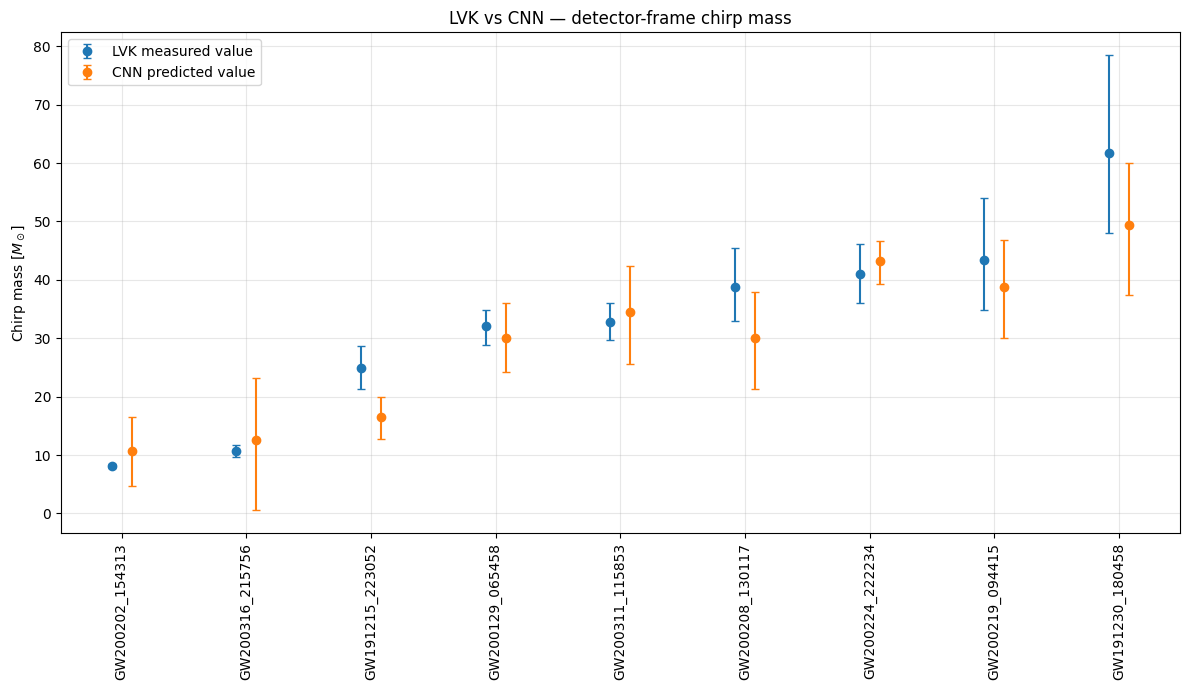

In [95]:
plot_lvk_vs_cnn_errorbars(
    comparison_df=comparison_multi_all_df,
    label="chirp_mass",
    ylabel=r"Chirp mass [$M_\odot$]",
    title="LVK vs CNN — detector-frame chirp mass",
    sort_by_lvk=True,
    output_path=OUTPUT_DIR / "lvk_vs_cnn_chirp_mass_all.png",
)

Saved: /data/vserrano/cbc_pe_data/results/bbh_processed_4s_seobnrv4opt_snr10-25_n500_000/real_events_m10_500k_lvk_comparison/lvk_vs_cnn_total_mass_all.png


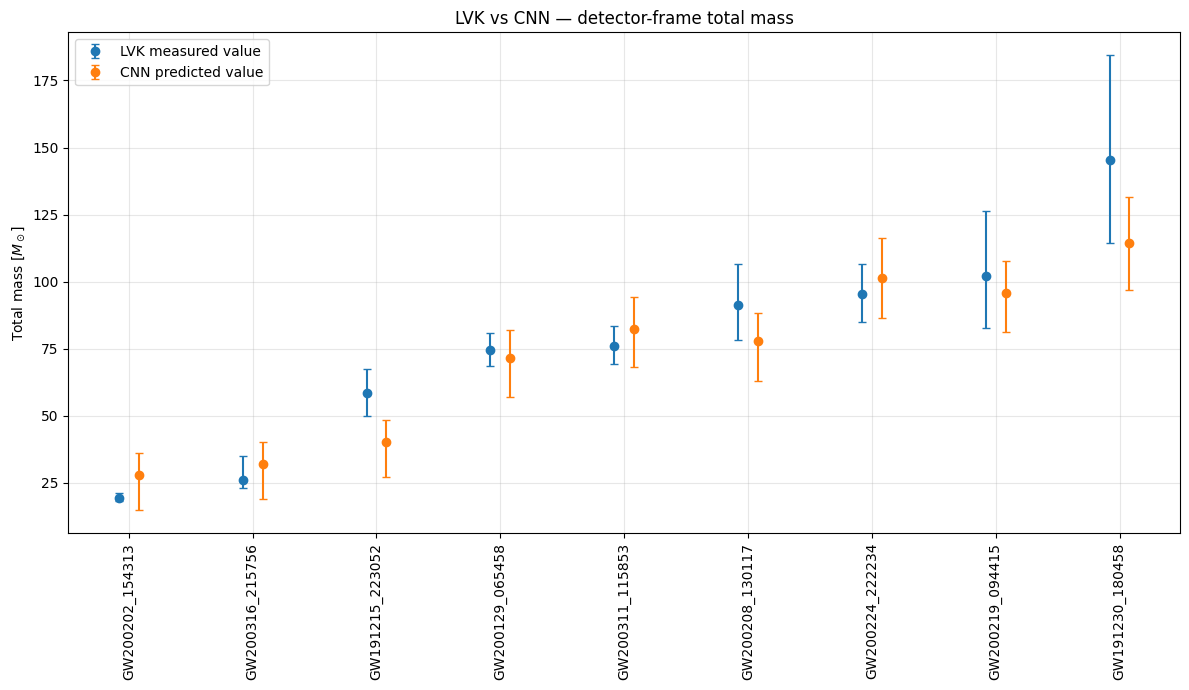

In [96]:
plot_lvk_vs_cnn_errorbars(
    comparison_df=comparison_multi_all_df,
    label="total_mass",
    ylabel=r"Total mass [$M_\odot$]",
    title="LVK vs CNN — detector-frame total mass",
    sort_by_lvk=True,
    output_path=OUTPUT_DIR / "lvk_vs_cnn_total_mass_all.png",
)

Saved: /data/vserrano/cbc_pe_data/results/bbh_processed_4s_seobnrv4opt_snr10-25_n500_000/real_events_m10_500k_lvk_comparison/lvk_vs_cnn_chi_eff_all.png


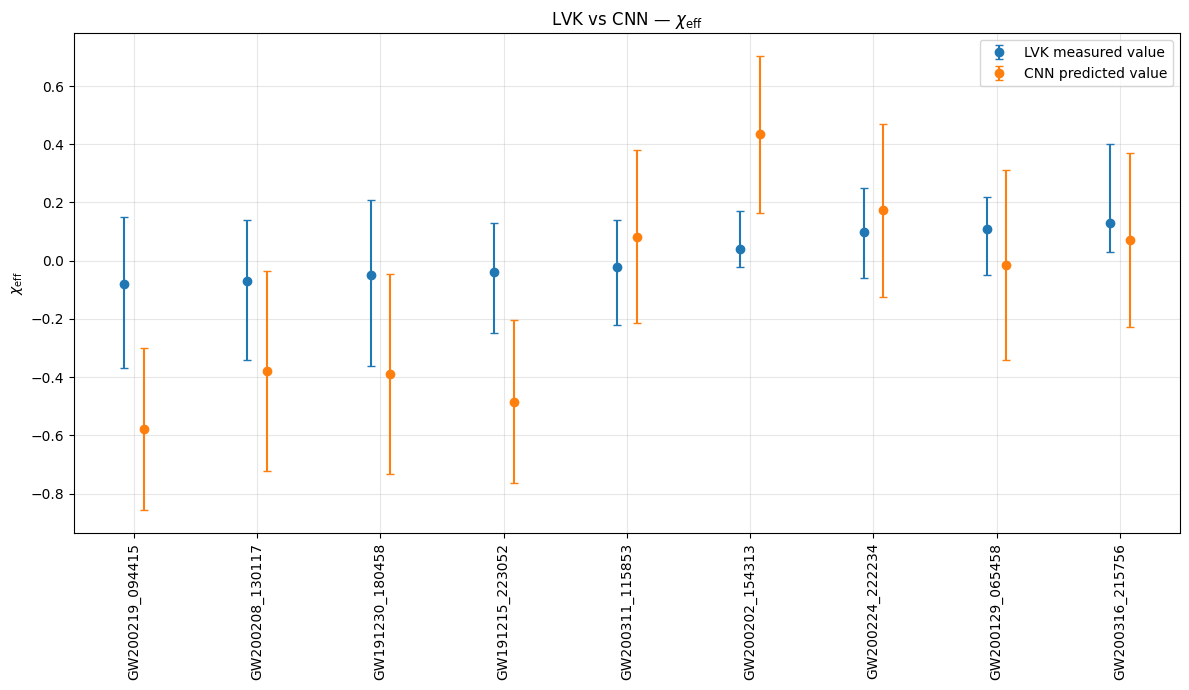

In [97]:
plot_lvk_vs_cnn_errorbars(
    comparison_df=comparison_multi_all_df,
    label="chi_eff",
    ylabel=r"$\chi_{\rm eff}$",
    title=r"LVK vs CNN — $\chi_{\rm eff}$",
    sort_by_lvk=True,
    output_path=OUTPUT_DIR / "lvk_vs_cnn_chi_eff_all.png",
)

## Final multi-event processing summary

The catalog-level selection yields 14 GWTC-3 confident events satisfying:

- H1/L1/V1 detector availability,
- detector-frame component masses in the approximate training range,
- network matched-filter SNR greater than 10.

All 14 selected events have complete H1/L1/V1 4096-s GWOSC strain URLs. After finite-strain quality checks, 9 events are processed successfully and 5 are excluded because the V1 event processing window contains non-finite samples.

The final comparison is therefore performed on the 9 successfully processed real events. LVK source-frame masses are converted to detector-frame masses with first-order uncertainty propagation in both source-frame mass and redshift. CNN intervals are the selected conservative Mondrian conformal intervals. Mass interval lower bounds are clipped at zero only for visualization; original conformal intervals are saved separately.

In [98]:
final_event_summary_cols = [
    "event",
    "network_snr_lvk",

    "chirp_mass_lvk",
    "chirp_mass_cnn",
    "chirp_mass_delta_cnn_minus_lvk",
    "chirp_mass_cnn_point_inside_lvk",
    "chirp_mass_lvk_median_inside_cnn",

    "total_mass_lvk",
    "total_mass_cnn",
    "total_mass_delta_cnn_minus_lvk",
    "total_mass_cnn_point_inside_lvk",
    "total_mass_lvk_median_inside_cnn",

    "chi_eff_lvk",
    "chi_eff_cnn",
    "chi_eff_delta_cnn_minus_lvk",
    "chi_eff_cnn_point_inside_lvk",
    "chi_eff_lvk_median_inside_cnn",
]

final_event_summary_df = comparison_multi_all_metrics_df[
    final_event_summary_cols
].copy()

display(final_event_summary_df)

,event,network_snr_lvk,chirp_mass_lvk,chirp_mass_cnn,chirp_mass_delta_cnn_minus_lvk,chirp_mass_cnn_point_inside_lvk,chirp_mass_lvk_median_inside_cnn,total_mass_lvk,total_mass_cnn,total_mass_delta_cnn_minus_lvk,total_mass_cnn_point_inside_lvk,total_mass_lvk_median_inside_cnn,chi_eff_lvk,chi_eff_cnn,chi_eff_delta_cnn_minus_lvk,chi_eff_cnn_point_inside_lvk,chi_eff_lvk_median_inside_cnn
0,GW191215_223052,11.2,24.8400,16.529647,-8.310353,False,False,58.4550,40.197370,-18.257630,False,False,-0.04,-0.483656,-0.443656,False,False
1,GW191230_180458,10.4,61.6850,49.379814,-12.305186,True,False,145.3400,114.462378,-30.877622,False,False,-0.05,-0.390034,-0.340034,False,True
2,GW200129_065458,26.8,32.0960,30.129896,-1.966104,True,True,74.6940,71.445609,-3.248391,True,True,0.11,-0.015243,-0.125243,True,True
3,GW200202_154313,10.8,8.1641,10.618011,2.453911,False,True,19.1622,27.853656,8.691456,False,True,0.04,0.433547,0.393547,False,False
4,GW200208_130117,10.8,38.7800,29.999662,-8.780338,False,False,91.4200,77.770844,-13.649156,False,False,-0.07,-0.377677,-0.307677,False,True
5,GW200219_094415,10.7,43.3320,38.829894,-4.502106,True,True,102.0500,95.698923,-6.351077,True,True,-0.08,-0.578843,-0.498843,False,False
6,GW200224_222234,20.0,41.0520,43.155595,2.103595,True,True,95.4360,101.233085,5.797085,True,True,0.10,0.172495,0.072495,True,True
7,GW200311_115853,17.8,32.7180,34.427157,1.709157,True,True,76.1370,82.485121,6.348121,True,True,-0.02,0.082605,0.102605,True,True
8,GW200316_215756,10.3,10.6750,12.507020,1.832020,False,True,25.8640,32.079116,6.215116,True,True,0.13,0.071046,-0.058954,True,True


In [99]:
def plot_delta_vs_lvk(
    comparison_df,
    label,
    xlabel,
    ylabel,
    title=None,
    output_path=None,
):
    df = comparison_df.copy()

    x = df[f"{label}_lvk"].values
    y = df[f"{label}_delta_cnn_minus_lvk"].values

    plt.figure(figsize=(7, 5))
    plt.axhline(0.0, linestyle="--", linewidth=1)

    plt.scatter(x, y)

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    if title is not None:
        plt.title(title)

    plt.grid(alpha=0.3)
    plt.tight_layout()

    if output_path is not None:
        plt.savefig(output_path, dpi=200)
        print("Saved:", output_path)

    plt.show()

Saved: /data/vserrano/cbc_pe_data/results/bbh_processed_4s_seobnrv4opt_snr10-25_n500_000/real_events_m10_500k_lvk_comparison/residual_vs_lvk_chirp_mass_all.png


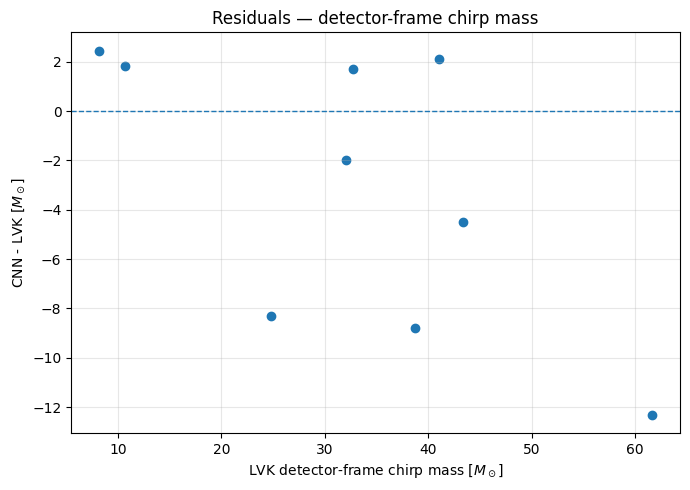

In [100]:
plot_delta_vs_lvk(
    comparison_df=comparison_multi_all_metrics_df,
    label="chirp_mass",
    xlabel=r"LVK detector-frame chirp mass [$M_\odot$]",
    ylabel=r"CNN - LVK [$M_\odot$]",
    title=r"Residuals — detector-frame chirp mass",
    output_path=OUTPUT_DIR / "residual_vs_lvk_chirp_mass_all.png",
)

Saved: /data/vserrano/cbc_pe_data/results/bbh_processed_4s_seobnrv4opt_snr10-25_n500_000/real_events_m10_500k_lvk_comparison/residual_vs_lvk_total_mass_all.png


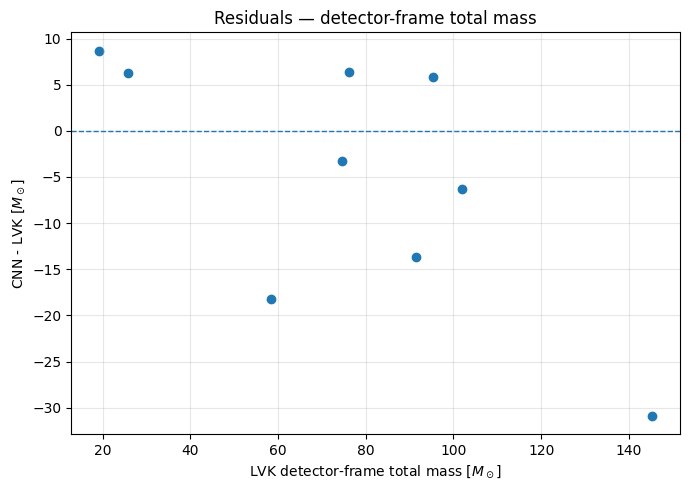

In [101]:
plot_delta_vs_lvk(
    comparison_df=comparison_multi_all_metrics_df,
    label="total_mass",
    xlabel=r"LVK detector-frame total mass [$M_\odot$]",
    ylabel=r"CNN - LVK [$M_\odot$]",
    title=r"Residuals — detector-frame total mass",
    output_path=OUTPUT_DIR / "residual_vs_lvk_total_mass_all.png",
)

Saved: /data/vserrano/cbc_pe_data/results/bbh_processed_4s_seobnrv4opt_snr10-25_n500_000/real_events_m10_500k_lvk_comparison/residual_vs_lvk_chi_eff_all.png


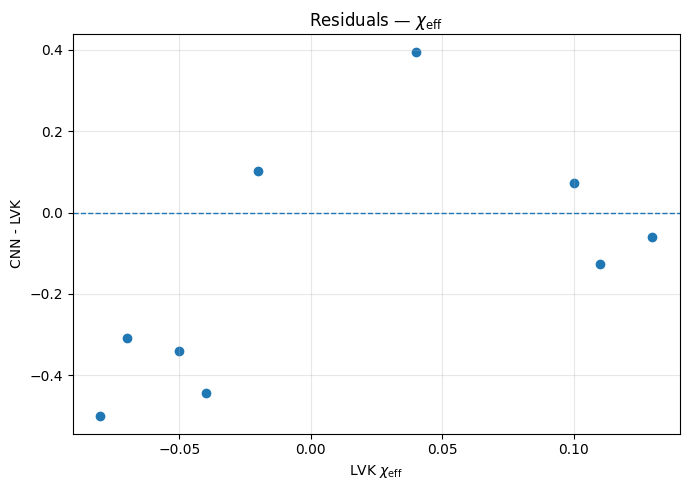

In [102]:
plot_delta_vs_lvk(
    comparison_df=comparison_multi_all_metrics_df,
    label="chi_eff",
    xlabel=r"LVK $\chi_{\rm eff}$",
    ylabel=r"CNN - LVK",
    title=r"Residuals — $\chi_{\rm eff}$",
    output_path=OUTPUT_DIR / "residual_vs_lvk_chi_eff_all.png",
)

In [103]:
final_event_summary_df.to_csv(
    OUTPUT_DIR / "multi_event_all_final_event_summary.csv",
    index=False,
)

print("Saved:", OUTPUT_DIR / "multi_event_all_final_event_summary.csv")

Saved: /data/vserrano/cbc_pe_data/results/bbh_processed_4s_seobnrv4opt_snr10-25_n500_000/real_events_m10_500k_lvk_comparison/multi_event_all_final_event_summary.csv


## Final multi-event conclusion

The final catalog-level selection contains 14 GWTC-3 confident events satisfying HLV detector availability, detector-frame component masses within the approximate training range, and network matched-filter SNR greater than 10. All 14 events have complete H1/L1/V1 4096-s GWOSC strain URLs.

After real-strain quality checks, 9 events are processed successfully. The remaining 5 are excluded because the V1 event processing window contains non-finite samples. These events are not interpolated or modified, since doing so would change the real detector input in a way not represented in the synthetic training/calibration distribution.

LVK source-frame masses are converted to detector-frame masses using \(M_{\rm det}=(1+z)M_{\rm source}\). The LVK mass intervals include first-order propagation of the source-frame mass and redshift uncertainties. This is an approximation; the exact treatment would require LVK posterior samples.

For the 9 processed events, the M10-500k model shows reasonable agreement with LVK detector-frame mass estimates. The chirp-mass comparison is the strongest, followed by total mass. The CNN exhibits a mild negative mass bias, especially for higher-mass events. The agreement for \(\chi_{\rm eff}\) is weaker, consistent with the synthetic test results and with the known difficulty of spin estimation from short real strain windows.

The Mondrian conformal intervals provide broad but useful uncertainty estimates. LVK median values fall inside the CNN/Mondrian intervals for approximately two thirds of the processed events across the three parameters. These intervals should be interpreted as split-conformal prediction intervals for the CNN estimator under the synthetic calibration distribution, not as Bayesian posterior credible intervals.